In [16]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
from glob import glob
import copy
from matplotlib.lines import Line2D


In [2]:
# Path for CMIP6Plus files
cmip6PlusTestingPath = "/p/user_pub/work/input4MIPs/CMIP6Plus/CMIP/CR/CR-CMIP-0-3-0/atmos"
paths = os.listdir(cmip6PlusTestingPath)
paths.sort()
paths

# for cmip6 data, installed esgpull on own machine, then ran below (also for mon) and uploaded 
# esgpull add --tag cmip6-global-mean-yearly --track project:input4MIPs mip_era:CMIP6 source_id:UoM-CMIP-1-2-0 grid_label:gr1-GMNHSH frequency:yr
# esgpull update -y --tag cmip6-global-mean-yearly
# esgpull download

cmip6Path = "/shared/FEoC-Forcing/cmip6_ghgs"


In [3]:

timestep = 'yr'

time_str_cmip6 = {
    "yr":"0000-2014",
    "mon":"000001-201412",
}   

species = os.listdir(f"{cmip6PlusTestingPath}/{timestep}/")
species.sort()
species

['ccl4',
 'cf4',
 'cfc11',
 'cfc113',
 'cfc114',
 'cfc115',
 'cfc11eq',
 'cfc12',
 'cfc12eq',
 'ch2cl2',
 'ch3br',
 'ch3cl',
 'ch4',
 'chcl3',
 'co2',
 'halon1211',
 'halon1301',
 'halon2402',
 'hcc140a',
 'hcfc141b',
 'hcfc142b',
 'hcfc22',
 'hfc125',
 'hfc134a',
 'hfc134aeq',
 'hfc143a',
 'hfc152a',
 'hfc227ea',
 'hfc23',
 'hfc236fa',
 'hfc245fa',
 'hfc32',
 'hfc365mfc',
 'hfc4310mee',
 'n2o',
 'nf3',
 'pfc116',
 'pfc218',
 'pfc3110',
 'pfc318',
 'pfc4112',
 'pfc5114',
 'pfc6116',
 'pfc7118',
 'sf6',
 'so2f2']

In [4]:
species_mon = os.listdir(f"{cmip6PlusTestingPath}/mon/")
species_mon.sort()
species == species_mon # confirm common set of species in monthly and yearly

True

In [5]:
# lifted from Zeb's script
CMIP6_TO_CMIP7_VARIABLE_MAP = {'mole_fraction_of_carbon_dioxide_in_air': 'co2',
 'mole_fraction_of_methane_in_air': 'ch4',
 'mole_fraction_of_nitrous_oxide_in_air': 'n2o',
 'mole_fraction_of_c2f6_in_air': 'c2f6',
 'mole_fraction_of_c3f8_in_air': 'c3f8',
 'mole_fraction_of_c4f10_in_air': 'c4f10',
 'mole_fraction_of_c5f12_in_air': 'c5f12',
 'mole_fraction_of_c6f14_in_air': 'c6f14',
 'mole_fraction_of_c7f16_in_air': 'c7f16',
 'mole_fraction_of_c8f18_in_air': 'c8f18',
 'mole_fraction_of_c_c4f8_in_air': 'cc4f8',
 'mole_fraction_of_carbon_tetrachloride_in_air': 'ccl4',
 'mole_fraction_of_cf4_in_air': 'cf4',
 'mole_fraction_of_cfc11_in_air': 'cfc11',
 'mole_fraction_of_cfc113_in_air': 'cfc113',
 'mole_fraction_of_cfc114_in_air': 'cfc114',
 'mole_fraction_of_cfc115_in_air': 'cfc115',
 'mole_fraction_of_cfc12_in_air': 'cfc12',
 'mole_fraction_of_ch2cl2_in_air': 'ch2cl2',
 'mole_fraction_of_methyl_bromide_in_air': 'ch3br',
 'mole_fraction_of_ch3ccl3_in_air': 'ch3ccl3',
 'mole_fraction_of_methyl_chloride_in_air': 'ch3cl',
 'mole_fraction_of_chcl3_in_air': 'chcl3',
 'mole_fraction_of_halon1211_in_air': 'halon1211',
 'mole_fraction_of_halon1301_in_air': 'halon1301',
 'mole_fraction_of_halon2402_in_air': 'halon2402',
 'mole_fraction_of_hcfc141b_in_air': 'hcfc141b',
 'mole_fraction_of_hcfc142b_in_air': 'hcfc142b',
 'mole_fraction_of_hcfc22_in_air': 'hcfc22',
 'mole_fraction_of_hfc125_in_air': 'hfc125',
 'mole_fraction_of_hfc134a_in_air': 'hfc134a',
 'mole_fraction_of_hfc143a_in_air': 'hfc143a',
 'mole_fraction_of_hfc152a_in_air': 'hfc152a',
 'mole_fraction_of_hfc227ea_in_air': 'hfc227ea',
 'mole_fraction_of_hfc23_in_air': 'hfc23',
 'mole_fraction_of_hfc236fa_in_air': 'hfc236fa',
 'mole_fraction_of_hfc245fa_in_air': 'hfc245fa',
 'mole_fraction_of_hfc32_in_air': 'hfc32',
 'mole_fraction_of_hfc365mfc_in_air': 'hfc365mfc',
 'mole_fraction_of_hfc4310mee_in_air': 'hfc4310mee',
 'mole_fraction_of_nf3_in_air': 'nf3',
 'mole_fraction_of_sf6_in_air': 'sf6',
 'mole_fraction_of_so2f2_in_air': 'so2f2',
 'mole_fraction_of_cfc11eq_in_air': 'cfc11eq',
 'mole_fraction_of_cfc12eq_in_air': 'cfc12eq',
 'mole_fraction_of_hfc134aeq_in_air': 'hfc134aeq'}


In [6]:
species_cmip6 = os.listdir(f"{cmip6Path}/{timestep}/")
species_cmip6.sort()
species_cmip6 = [i.split("_")[0].replace("-", "_") for i in species_cmip6]
species_cmip6
for specie_cmip6 in species_cmip6:
    if CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6] not in species:
        print(f"CMIP6 specie {CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6]} not in CMIP6Plus")

print("\n")
for specie in species:
    if specie not in list(CMIP6_TO_CMIP7_VARIABLE_MAP.values()):
        print(f"CMIP6Plus specie {specie} not in CMIP6")
        #print(f"'{specie}':'',")


# interesting?

CMIP6 specie cc4f8 not in CMIP6Plus
CMIP6 specie c2f6 not in CMIP6Plus
CMIP6 specie c3f8 not in CMIP6Plus
CMIP6 specie c4f10 not in CMIP6Plus
CMIP6 specie c5f12 not in CMIP6Plus
CMIP6 specie c6f14 not in CMIP6Plus
CMIP6 specie c7f16 not in CMIP6Plus
CMIP6 specie c8f18 not in CMIP6Plus
CMIP6 specie ch3ccl3 not in CMIP6Plus


CMIP6Plus specie hcc140a not in CMIP6
CMIP6Plus specie pfc116 not in CMIP6
CMIP6Plus specie pfc218 not in CMIP6
CMIP6Plus specie pfc3110 not in CMIP6
CMIP6Plus specie pfc318 not in CMIP6
CMIP6Plus specie pfc4112 not in CMIP6
CMIP6Plus specie pfc5114 not in CMIP6
CMIP6Plus specie pfc6116 not in CMIP6
CMIP6Plus specie pfc7118 not in CMIP6


In [7]:
cmip6_to_cmip6plus = {
    'mole_fraction_of_ch3ccl3_in_air':'hcc140a',
    'mole_fraction_of_c2f6_in_air':'pfc116',
    'mole_fraction_of_c3f8_in_air':'pfc218',
    'mole_fraction_of_c4f10_in_air':'pfc3110',
    'mole_fraction_of_c_c4f8_in_air':'pfc318',
    'mole_fraction_of_c5f12_in_air':'pfc4112',
    'mole_fraction_of_c6f14_in_air':'pfc5114',
    'mole_fraction_of_c7f16_in_air':'pfc6116',
    'mole_fraction_of_c8f18_in_air':'pfc7118',
    }

for changed_spec in cmip6_to_cmip6plus.keys():
    CMIP6_TO_CMIP7_VARIABLE_MAP[changed_spec] = cmip6_to_cmip6plus[changed_spec]  




In [8]:
spec_data = {}
spec_data['fname'] = {}
spec_data['time'] = {}
spec_data['data'] = {}

spec_data_cmip6 = {}
spec_data_cmip6['fname'] = {}
spec_data_cmip6['time'] = {}
spec_data_cmip6['data'] = {}

common_cmip6_species = []

units_conv_cmip6_cmipplus = {
    "1.e-6":"ppm",
    "1.e-9":"ppb",
    "1.e-12":"ppt",
}
    

for specie_cmip6 in species_cmip6:
    if CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6] not in species:
        print(f' IGNORE {specie_cmip6} {CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6]}')
        continue    

    common_cmip6_species.append(specie_cmip6)

    # cmip6plus

    specie = CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6]

    print(specie)
    
    
    data_folders = os.listdir(f"{cmip6PlusTestingPath}/{timestep}/{specie}/gm/")
    if len(data_folders) > 1:
        print(f'{len(data_folders)} for {specie}')
    data_folder = data_folders[0]

    files = os.listdir(f"{cmip6PlusTestingPath}/{timestep}/{specie}/gm/{data_folder}/")

    if len(files) > 1:
        print(f'{len(files)} for {specie}')

    file = f"{cmip6PlusTestingPath}/{timestep}/{specie}/gm/{data_folder}/{files[0]}"

    spec_data['fname'][specie] = file
    
    with xr.open_dataset(file, use_cftime=True) as ds:
        ds.convert_calendar("proleptic_gregorian")
        spec_data['time'][specie] = ds['time']
        spec_data['data'][specie] = ds[specie]

        cmip6plus_units = ds[specie].attrs["units"]
        
    # cmip6


    file_cmip6 = (f"{cmip6Path}/{timestep}/{specie_cmip6.replace('_', '-')}"
                f"_input4MIPs_GHGConcentrations_CMIP_UoM-CMIP-1-2-0_gr1-GMNHSH_{time_str_cmip6[timestep]}.nc")

    spec_data_cmip6['fname'][specie] = file_cmip6


    # also cribbed from Zeb
    out = xr.open_dataset(file_cmip6, decode_times=False)
    
    if out.attrs["frequency"] == "yr":
        out = out.isel(time=slice(1, None))
    
    else:
        out = out.isel(time=slice(12, None))
    
    if out["time"].attrs["units"] == "days since 0-1-1":
        out["time"].attrs["units"] =  "days since 0001-1-1"
        old_attrs = out["time"].attrs
        out["time"] = out["time"] - 365
        out["time"].attrs = old_attrs
    
    out = xr.decode_cf(out, decode_times=True, use_cftime=True)

    cmip6_units = out[specie_cmip6].attrs["units"]

    spec_data_cmip6['time'][specie] = out['time']
    spec_data_cmip6['data'][specie] = out[specie_cmip6]
    
    #print(f'{cmip6_units} {cmip6plus_units}')

    if units_conv_cmip6_cmipplus[cmip6_units] != cmip6plus_units:
        print(f'Different units {specie}: {cmip6_units} {cmip6plus_units}')

    



pfc318
pfc116
pfc218
pfc3110
pfc4112
pfc5114
pfc6116
pfc7118
co2
ccl4
cf4
cfc11
cfc113
cfc114
cfc115
cfc11eq
cfc12
cfc12eq
ch2cl2
hcc140a
chcl3
halon1211
halon1301
halon2402
hcfc141b
hcfc142b
hcfc22
hfc125
hfc134a
hfc134aeq
hfc143a
hfc152a
hfc227ea
hfc23
hfc236fa
hfc245fa
hfc32
hfc365mfc
hfc4310mee
ch4
ch3br
ch3cl
nf3
n2o
sf6
so2f2


In [9]:
for specie in common_cmip6_species:
    
    if spec_data['time'][CMIP6_TO_CMIP7_VARIABLE_MAP[specie]].equals(
        spec_data['time'][CMIP6_TO_CMIP7_VARIABLE_MAP[common_cmip6_species[0]]]) != True:
        print(f'{specie} different')

# all time dimensions are the same
    

/opt/conda/lib/python3.10/site-packages/nc_time_axis/__init__.py:359: CFWarning: this date/calendar/year zero convention is not supported by CF
  lower = cftime.num2date(vmin, self.date_unit, calendar=self.calendar)
/opt/conda/lib/python3.10/site-packages/nc_time_axis/__init__.py:376: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.datetime(
/opt/conda/lib/python3.10/site-packages/nc_time_axis/__init__.py:454: CFWarning: this date/calendar/year zero convention is not supported by CF
  return cftime.date2num(ticks, self.date_unit, calendar=self.calendar)
/opt/conda/lib/python3.10/site-packages/nc_time_axis/__init__.py:228: CFWarning: this date/calendar/year zero convention is not supported by CF
  dt = cftime.num2date(x, self.time_units, calendar=self.calendar)
/opt/conda/lib/python3.10/site-packages/nc_time_axis/__init__.py:359: CFWarning: this date/calendar/year zero convention is not supported by CF
  lower = cftime.num2date(vmin, self.date_unit, ca

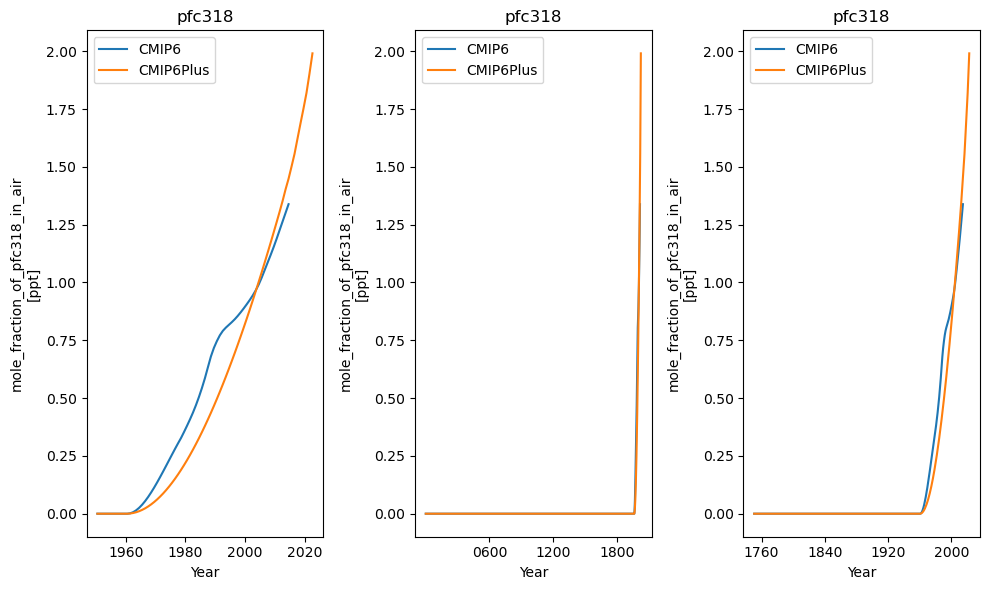

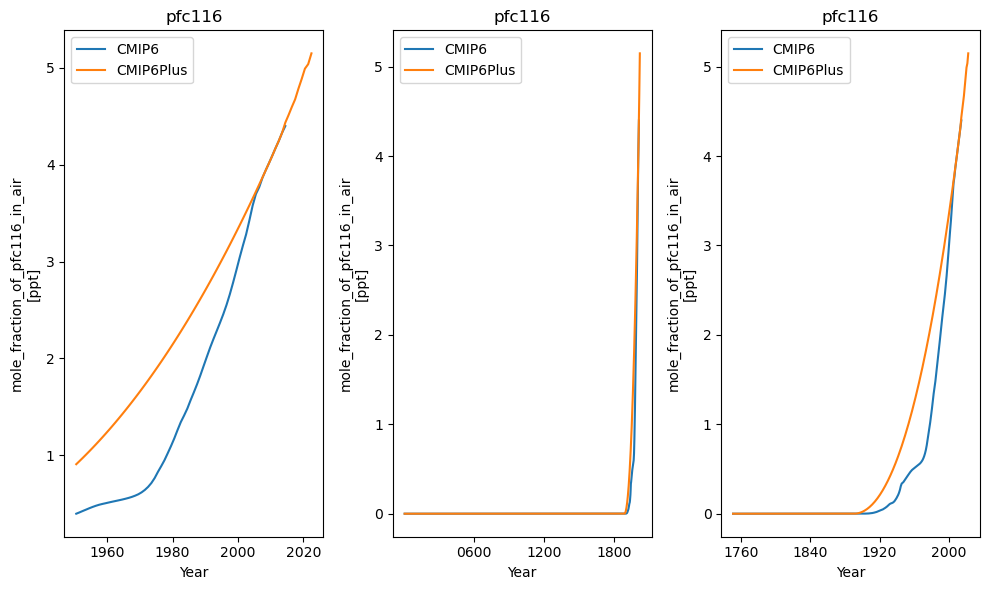

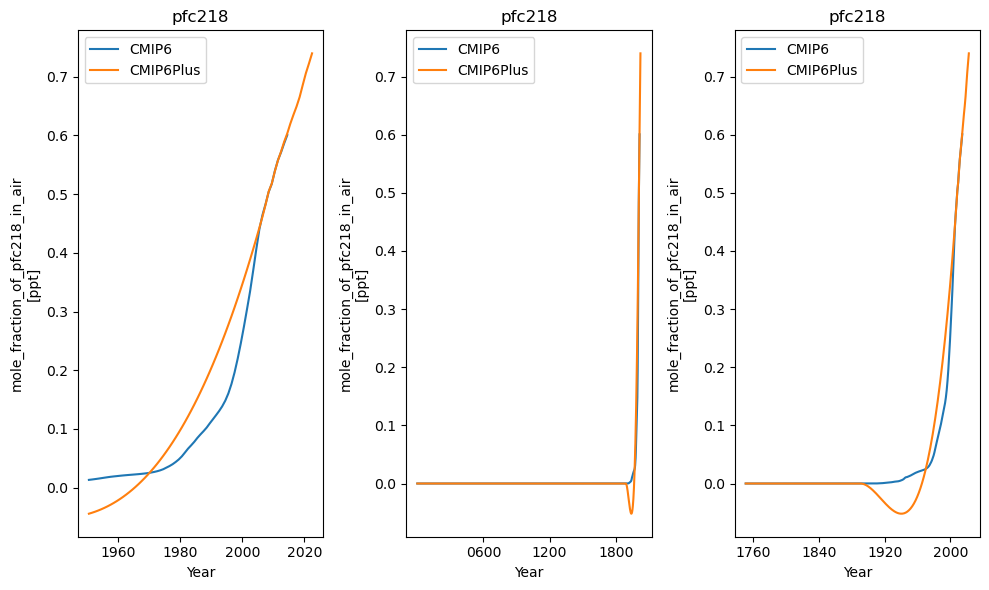

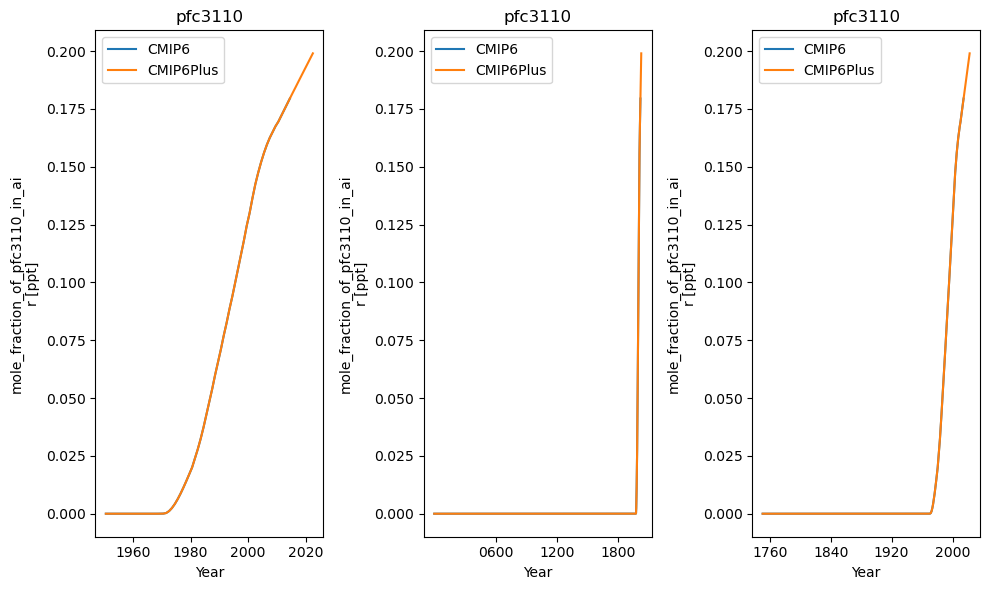

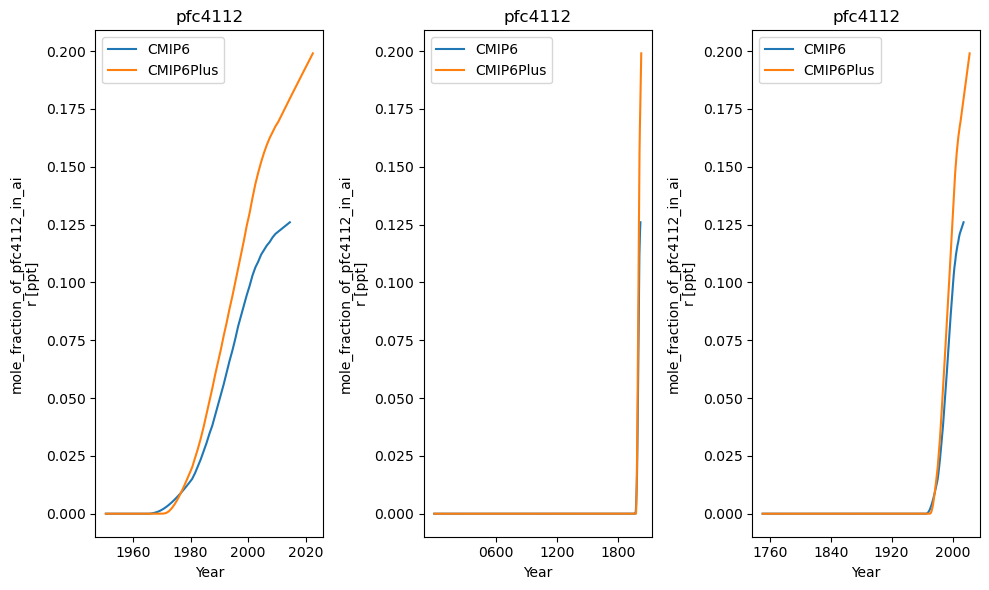

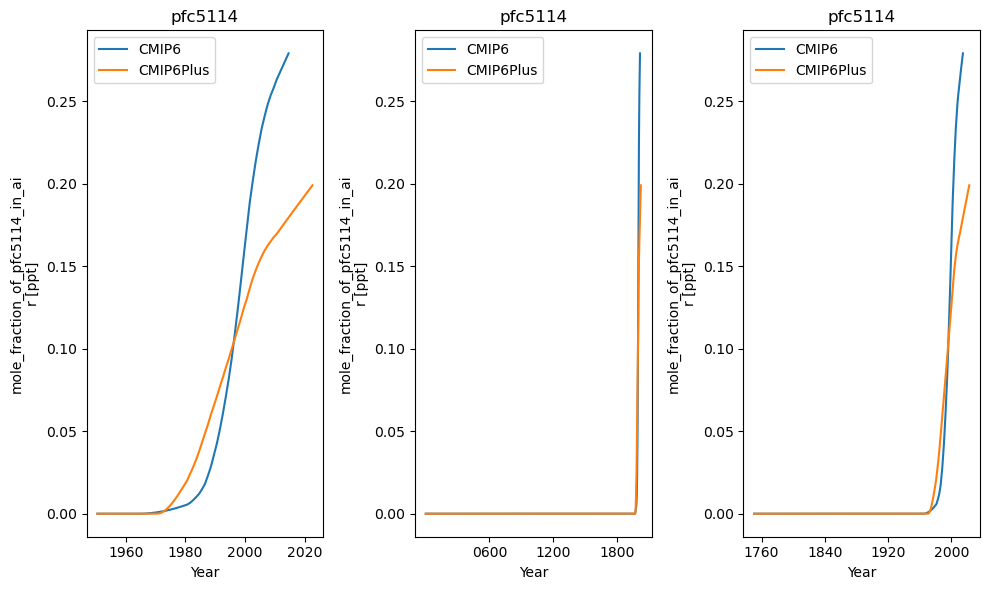

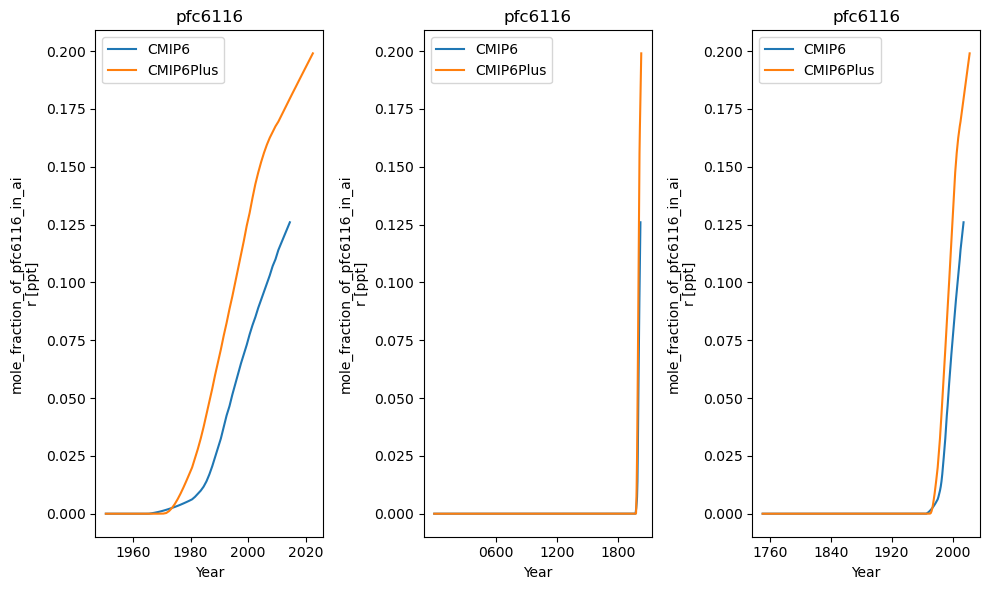

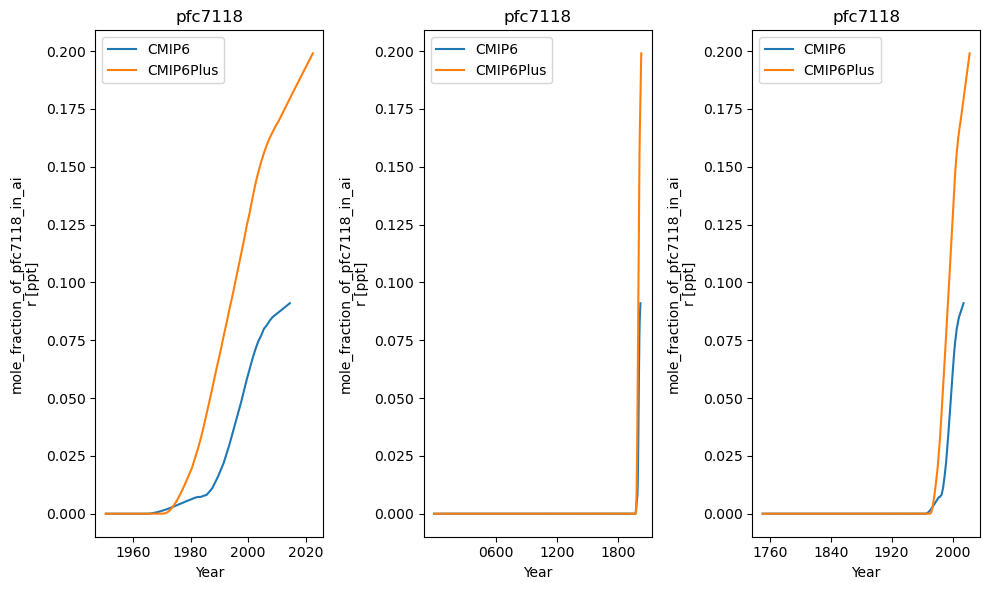

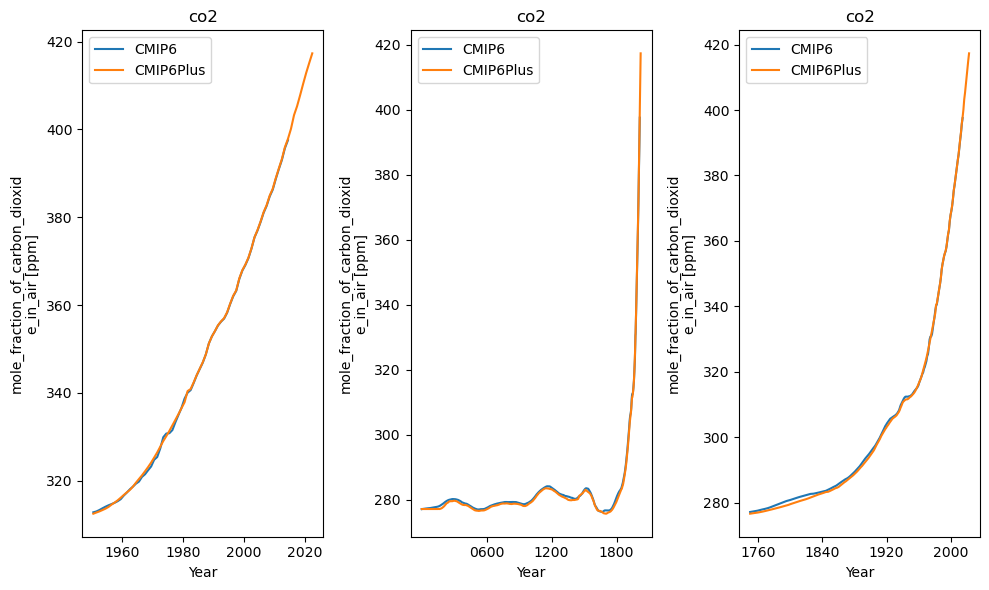

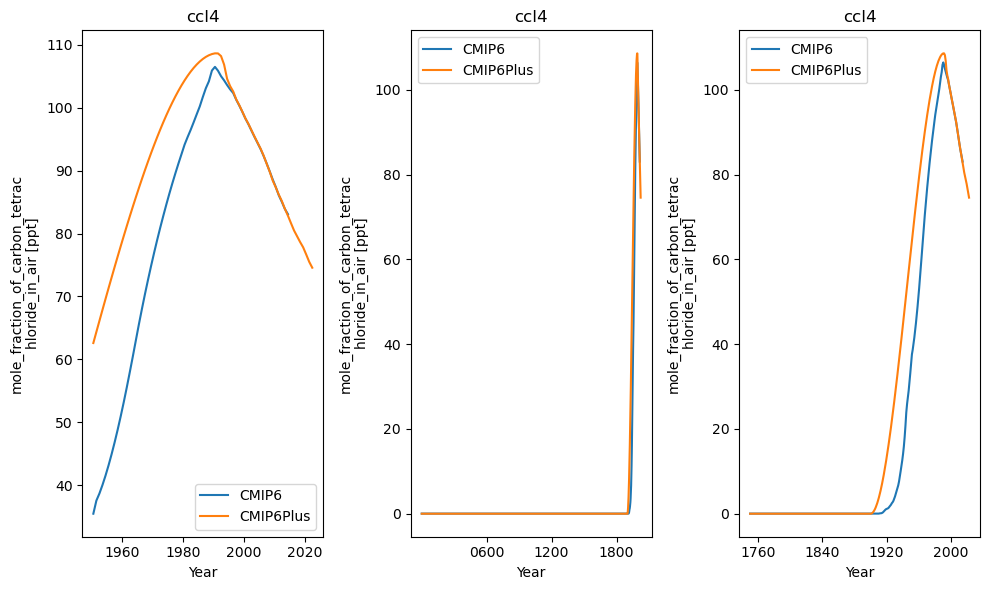

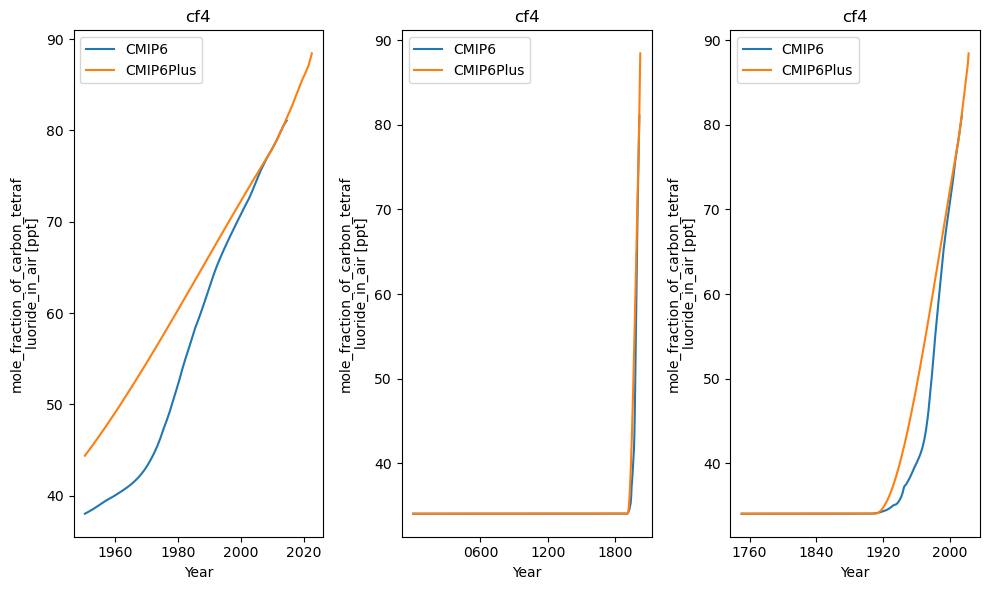

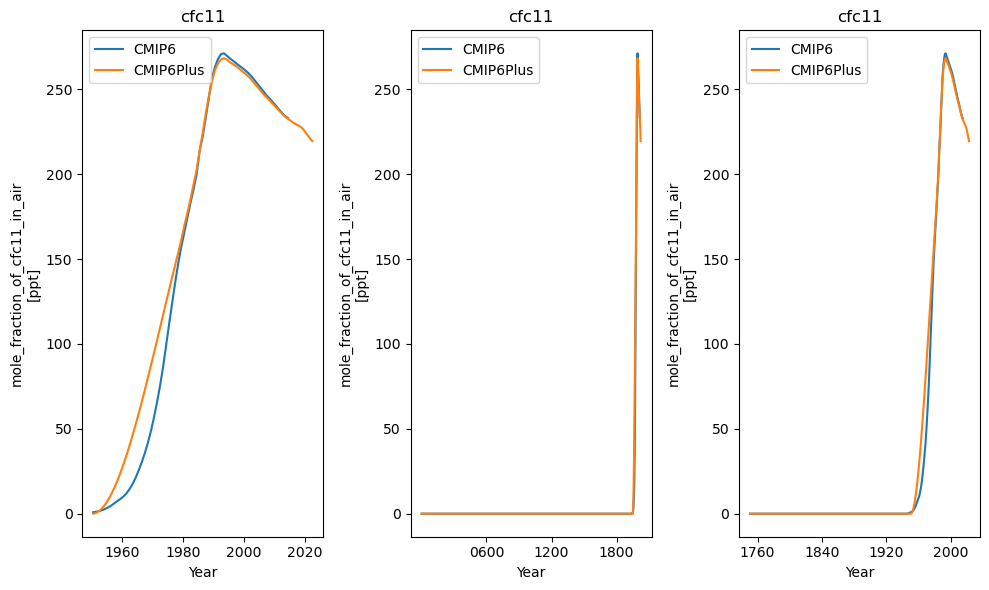

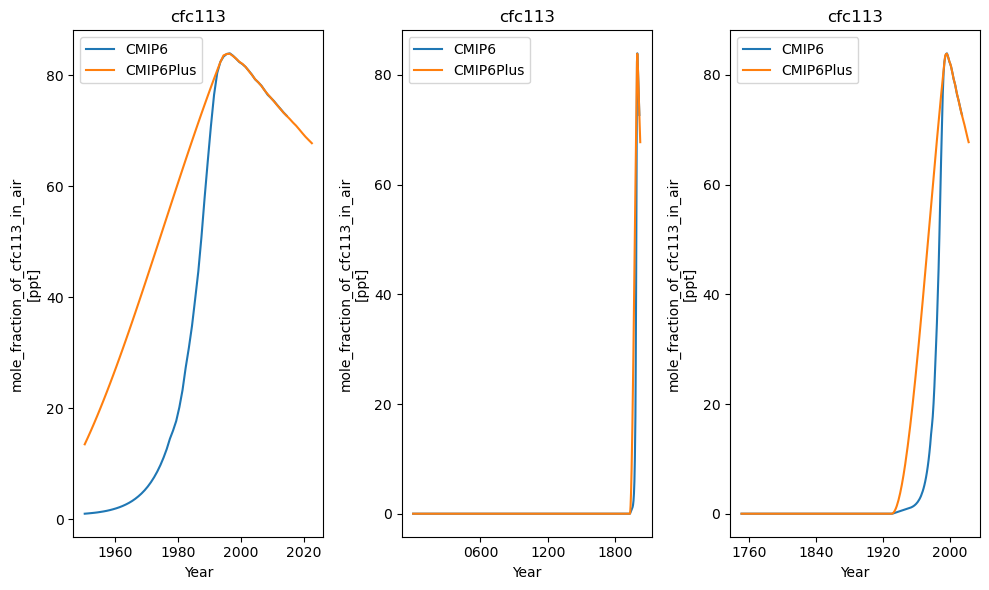

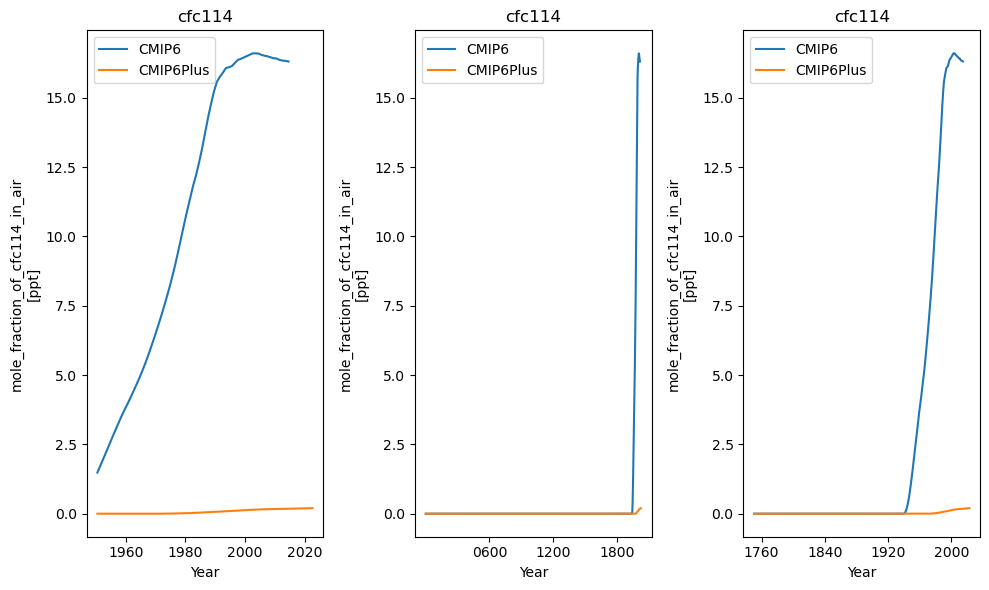

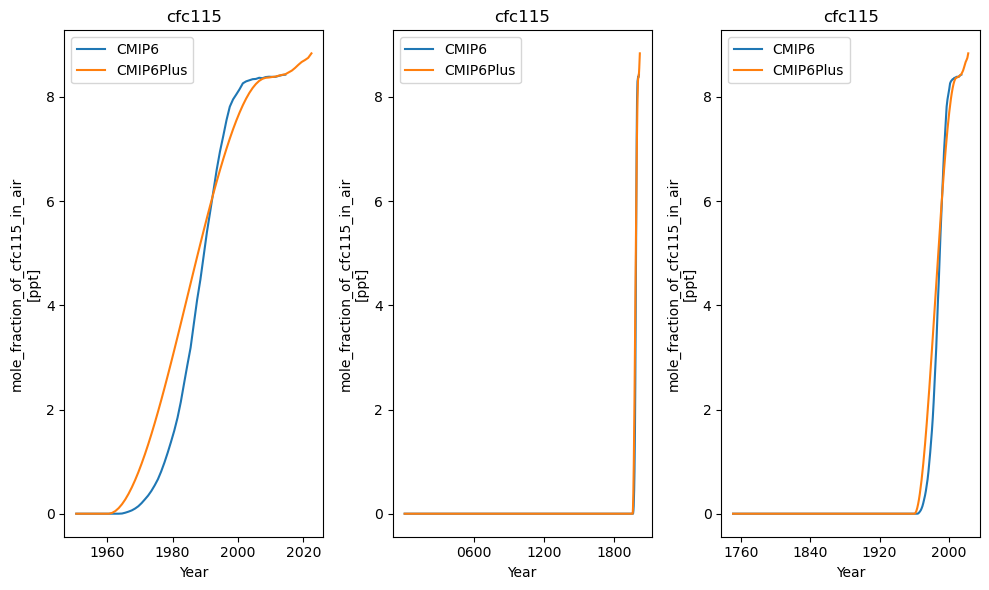

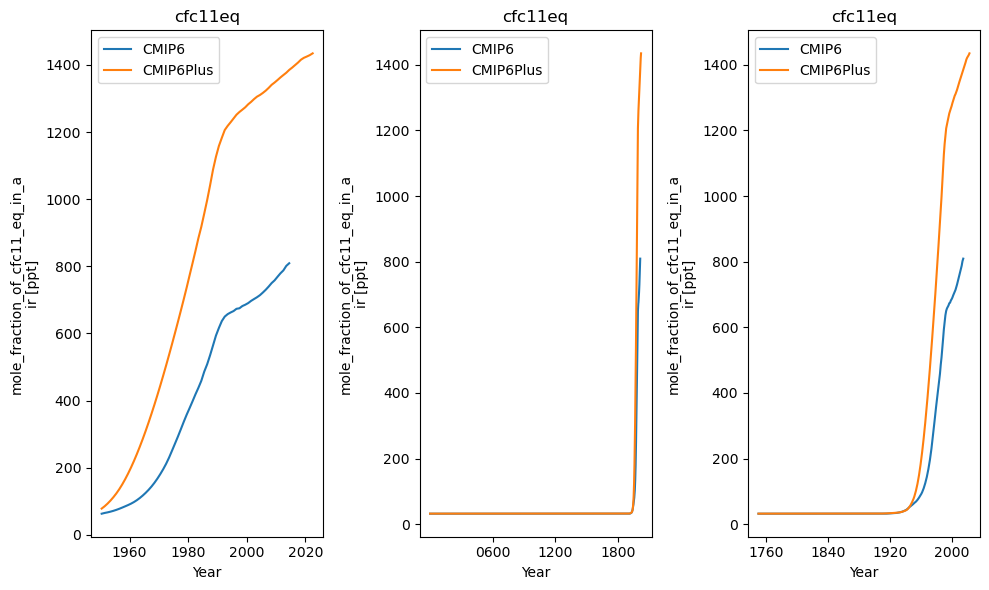

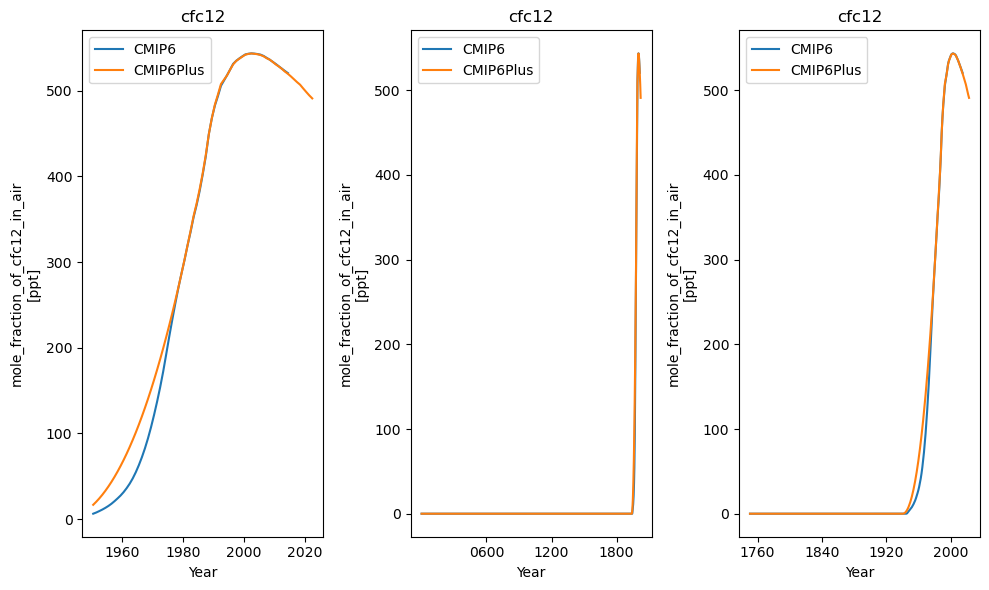

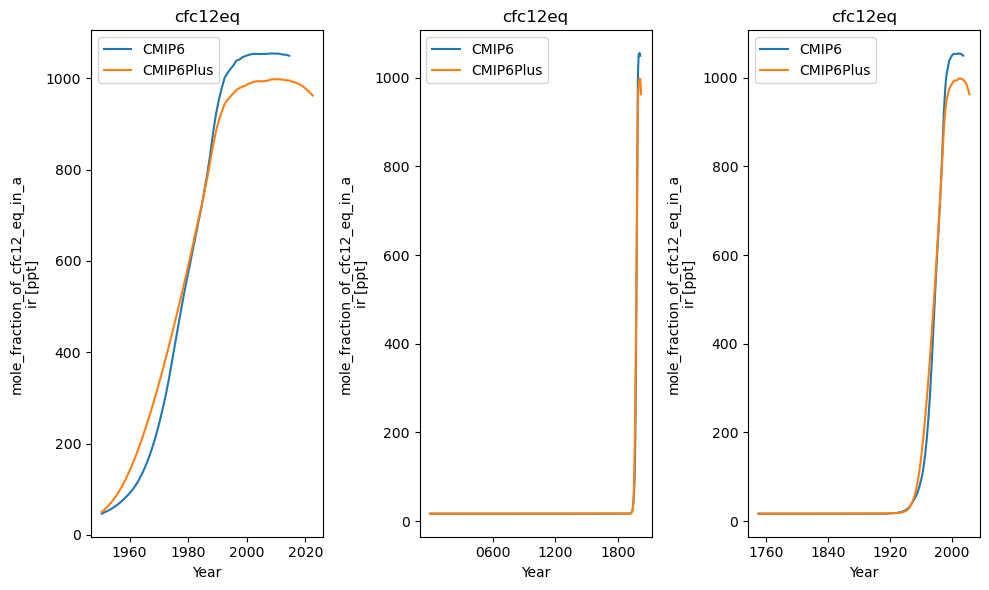

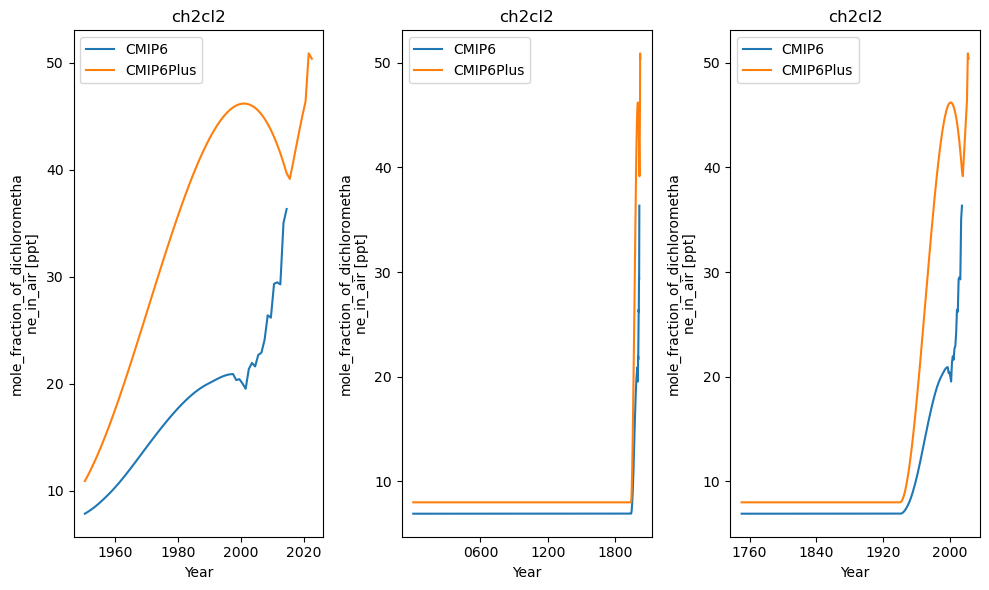

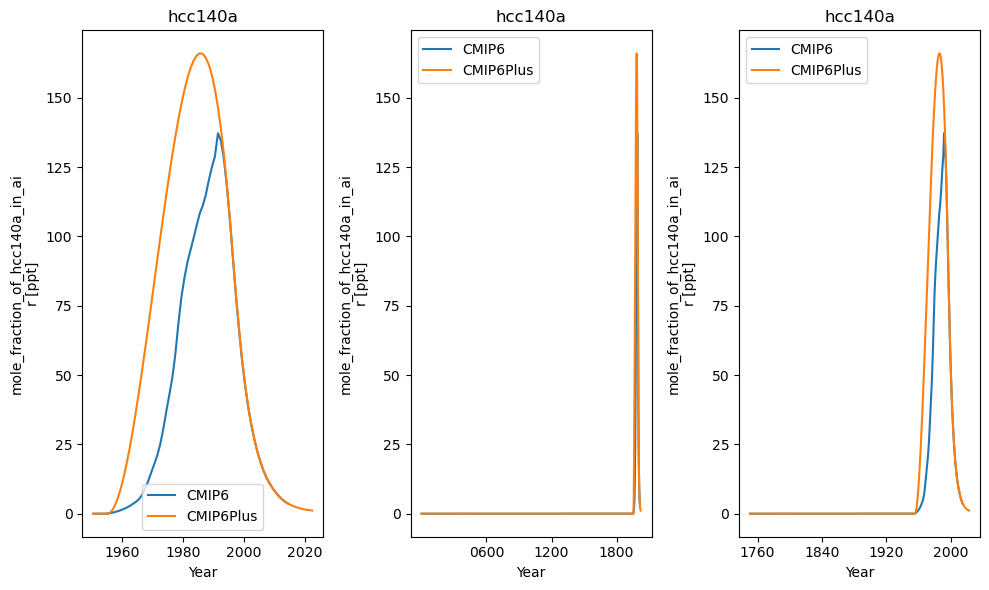

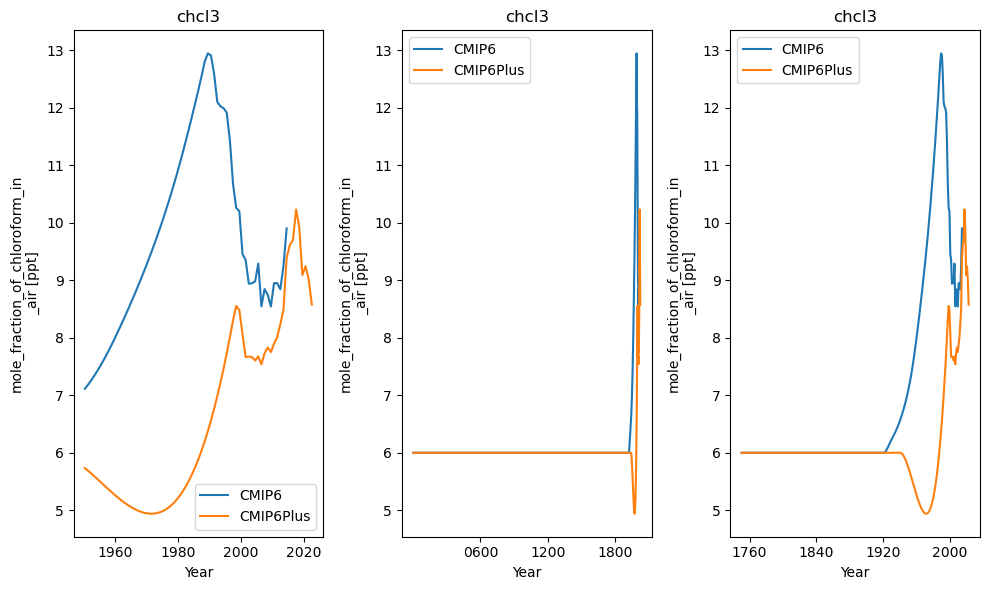

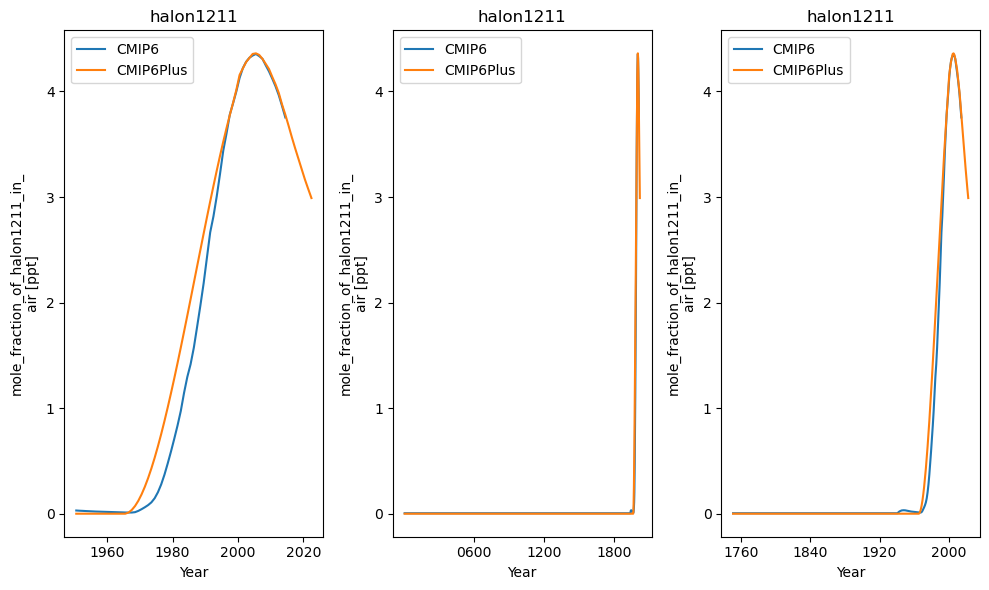

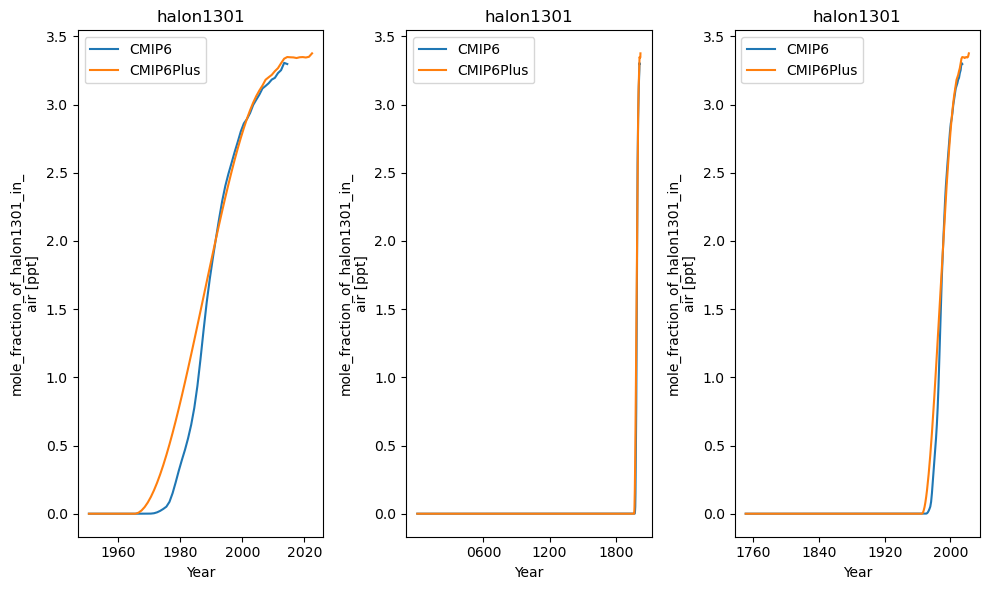

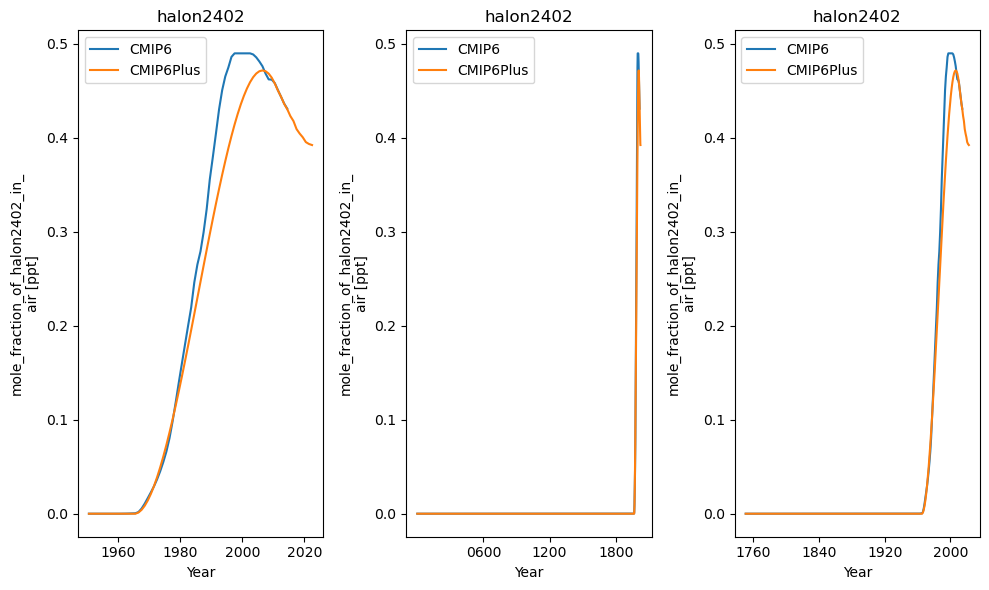

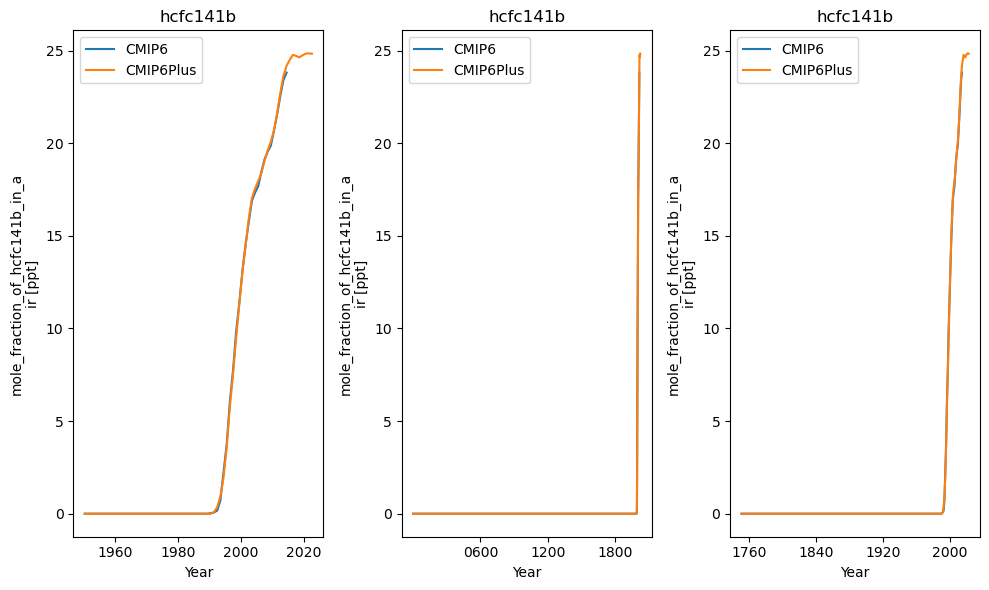

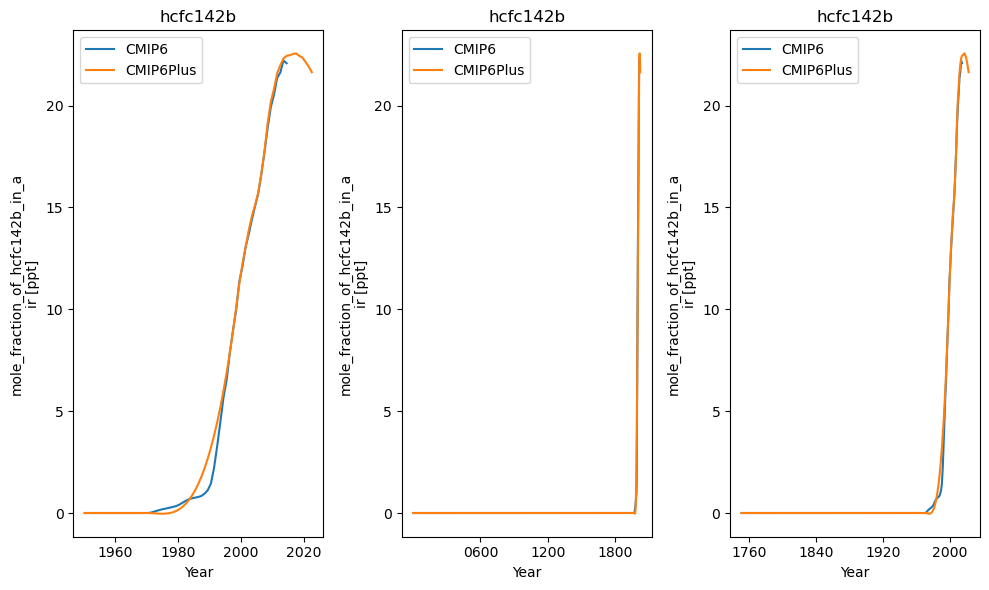

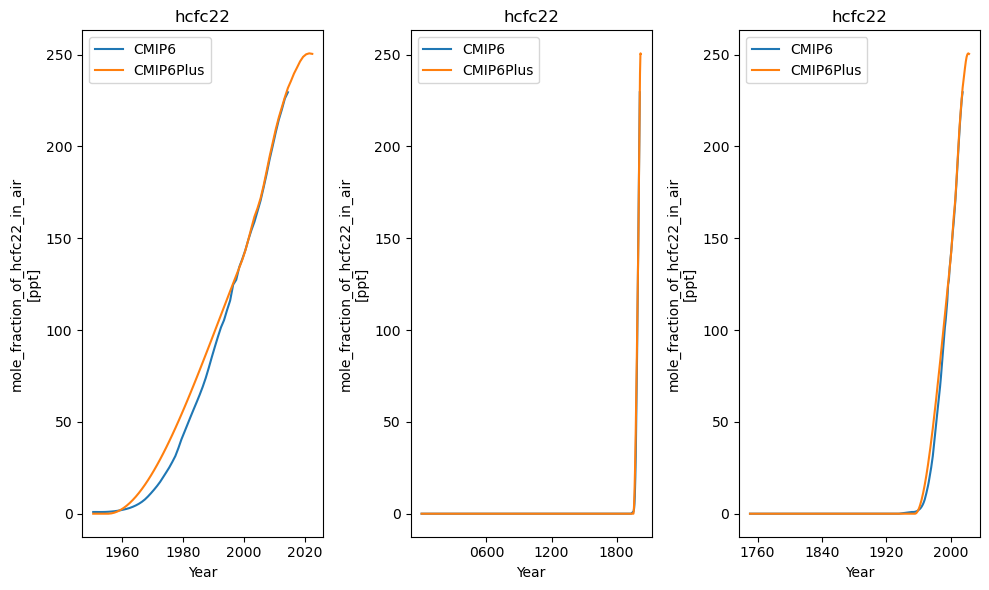

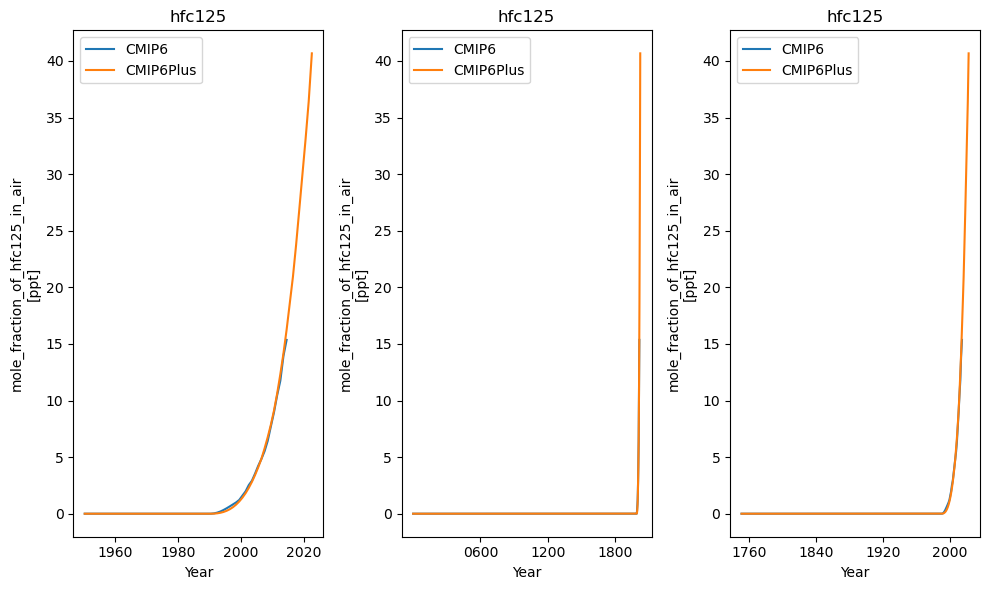

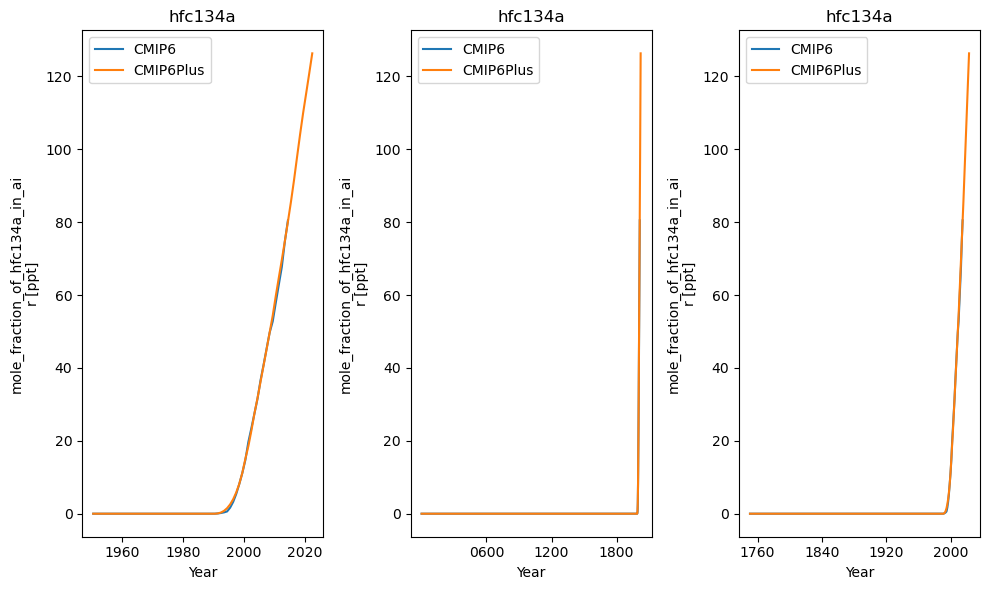

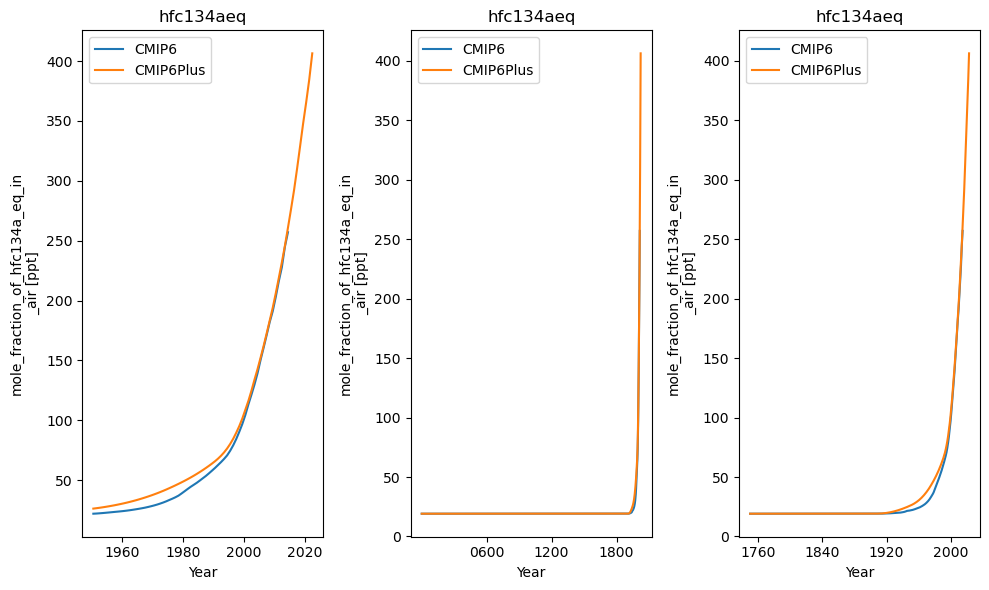

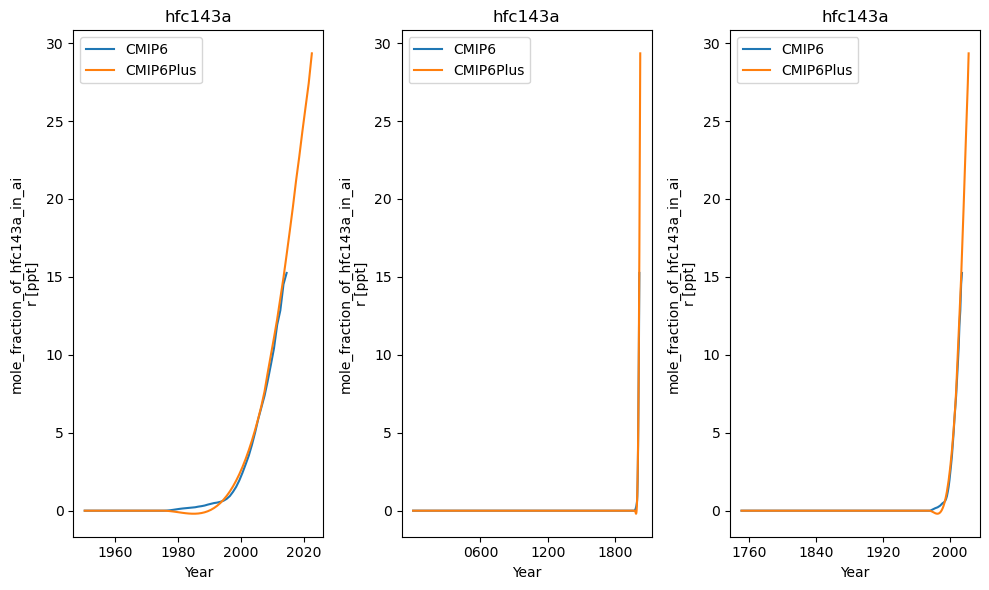

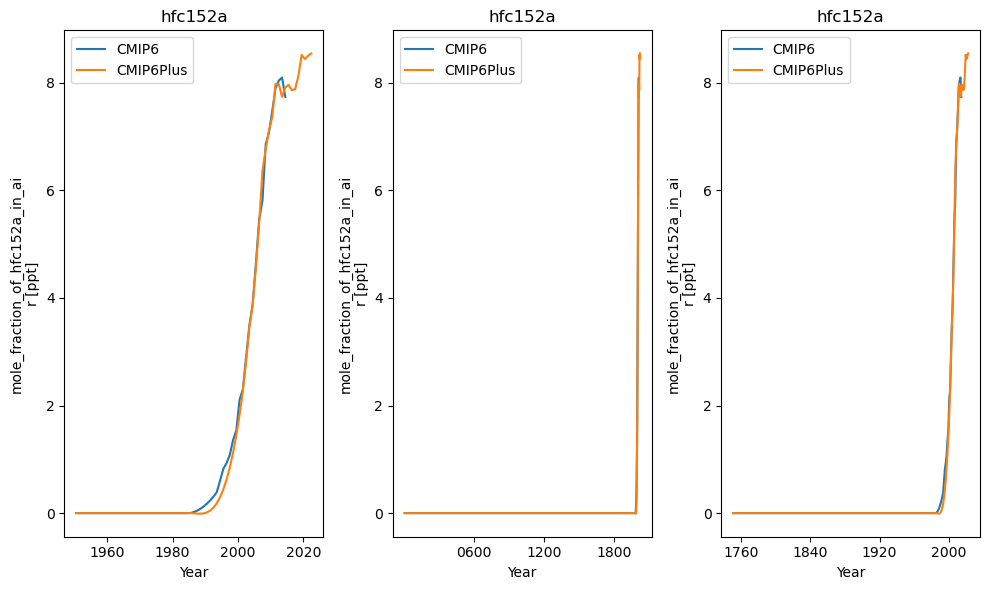

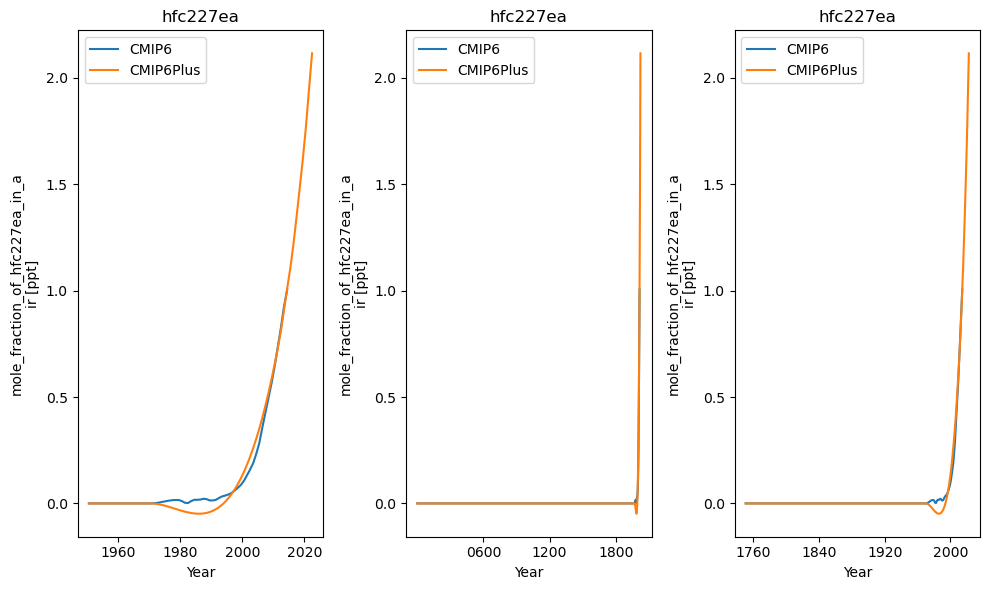

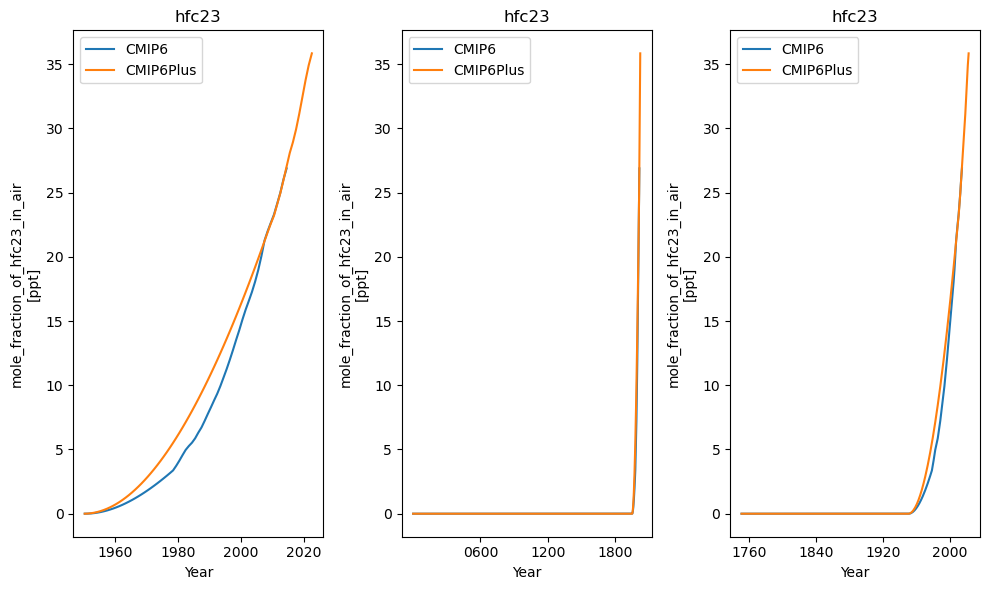

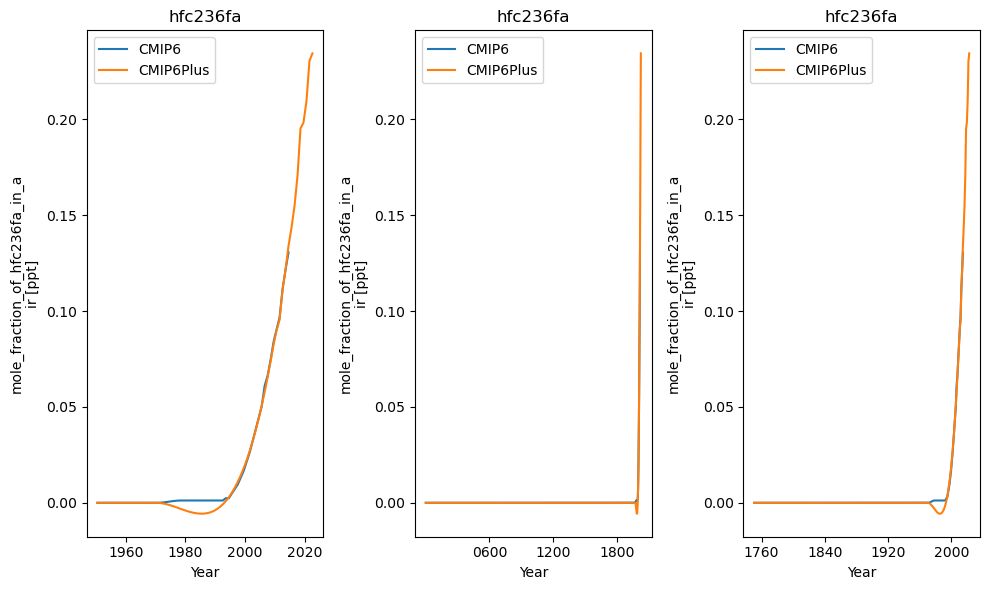

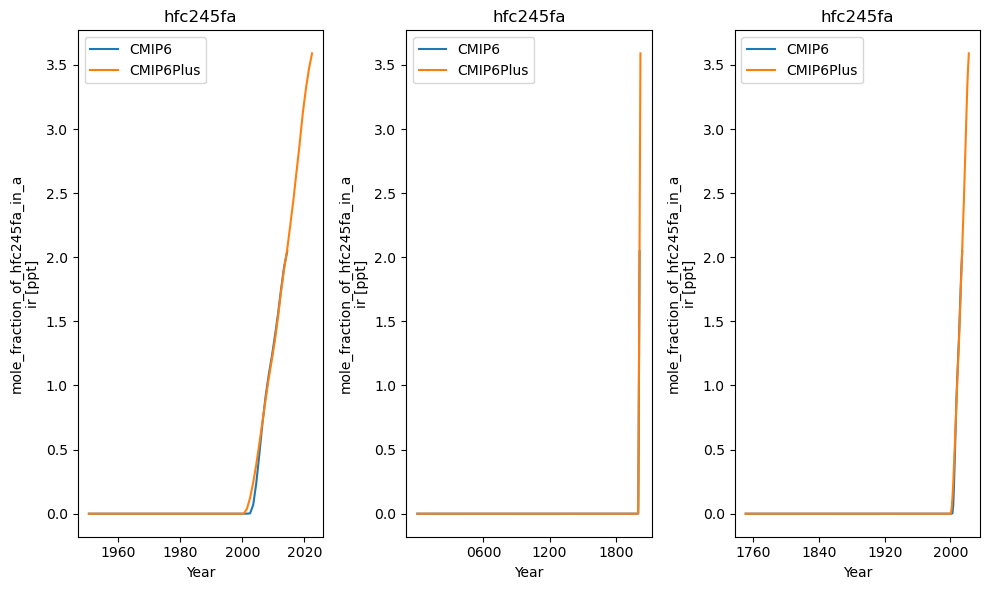

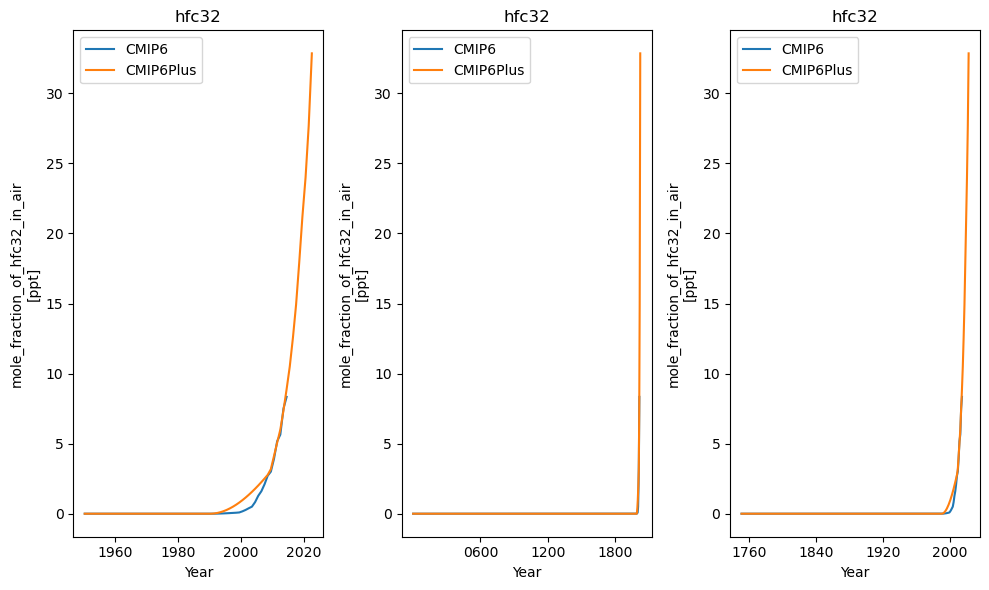

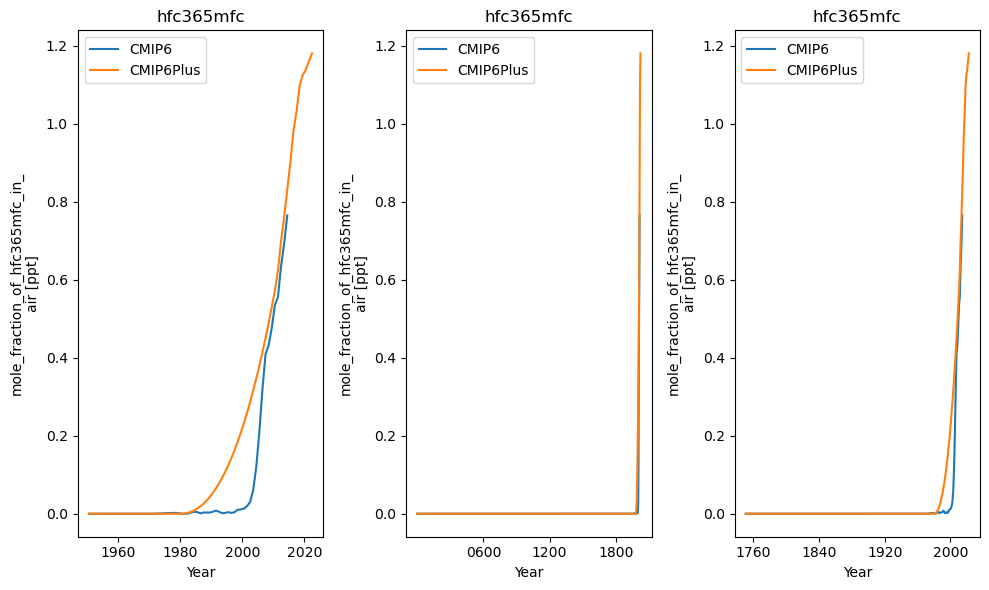

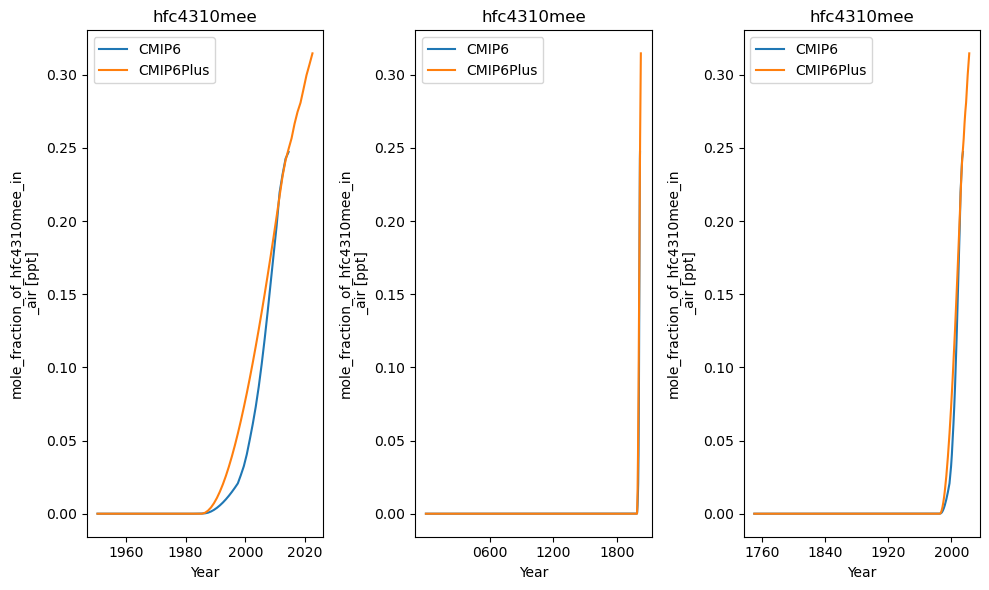

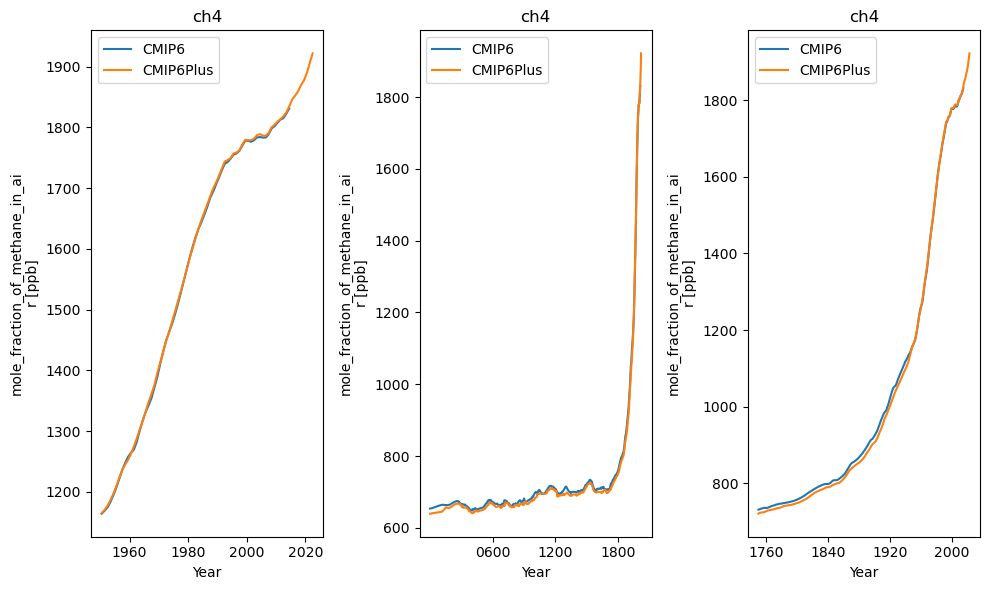

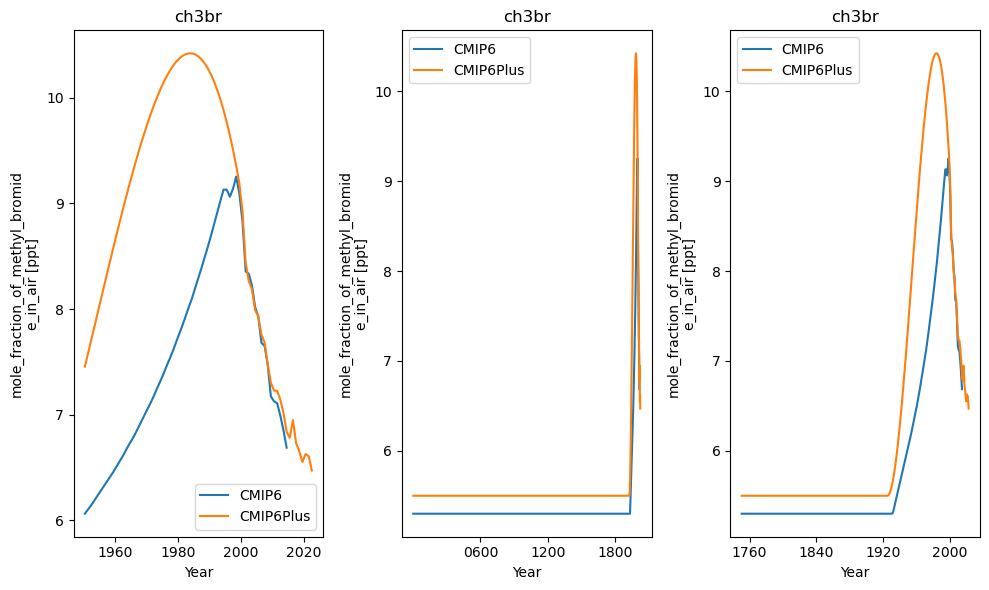

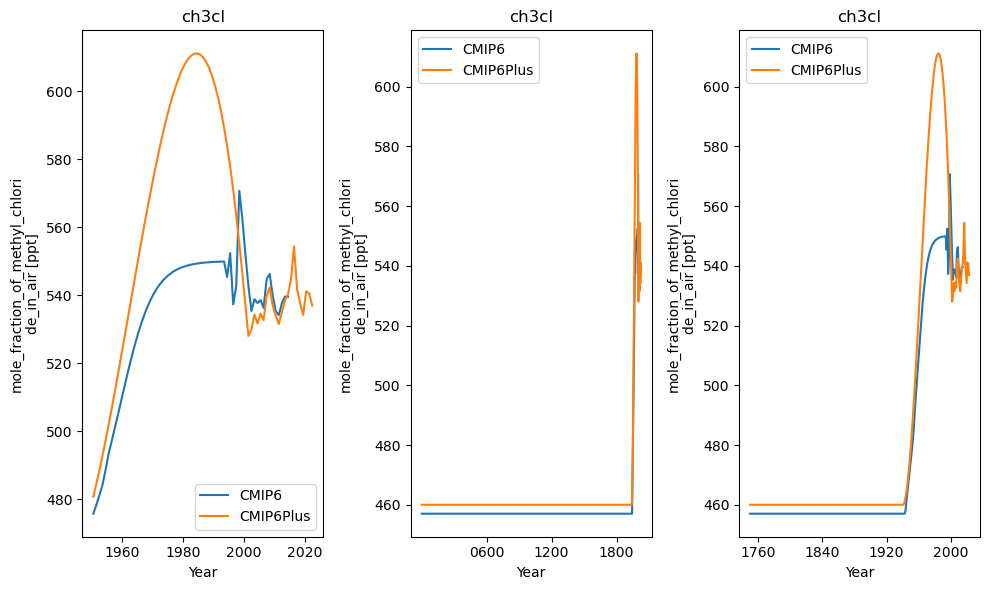

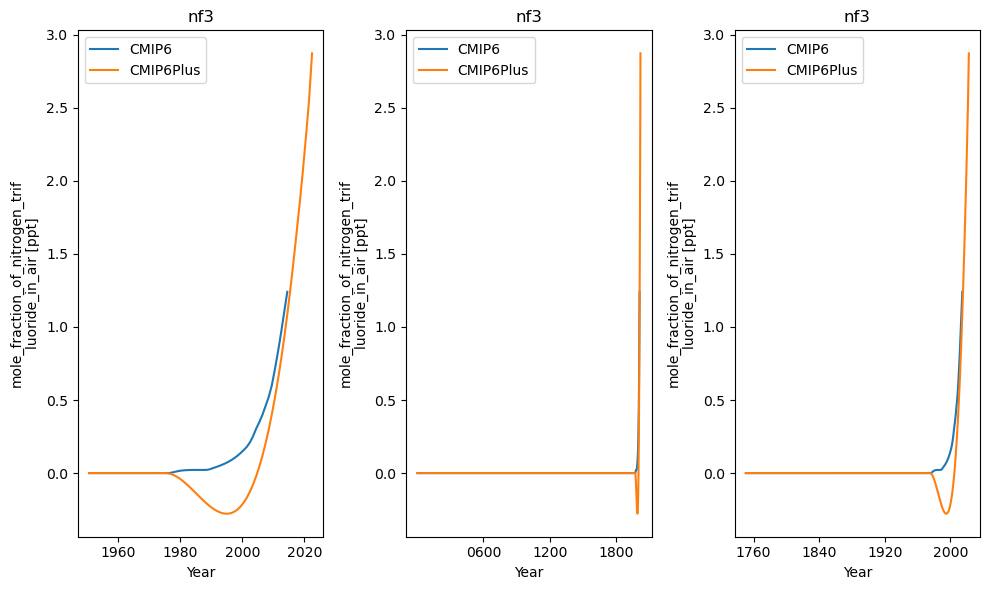

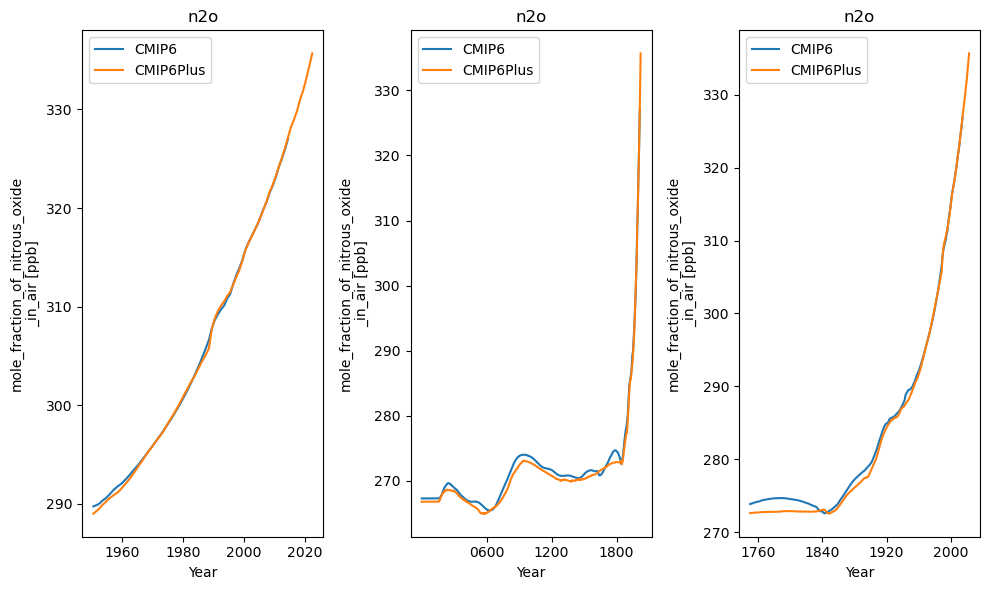

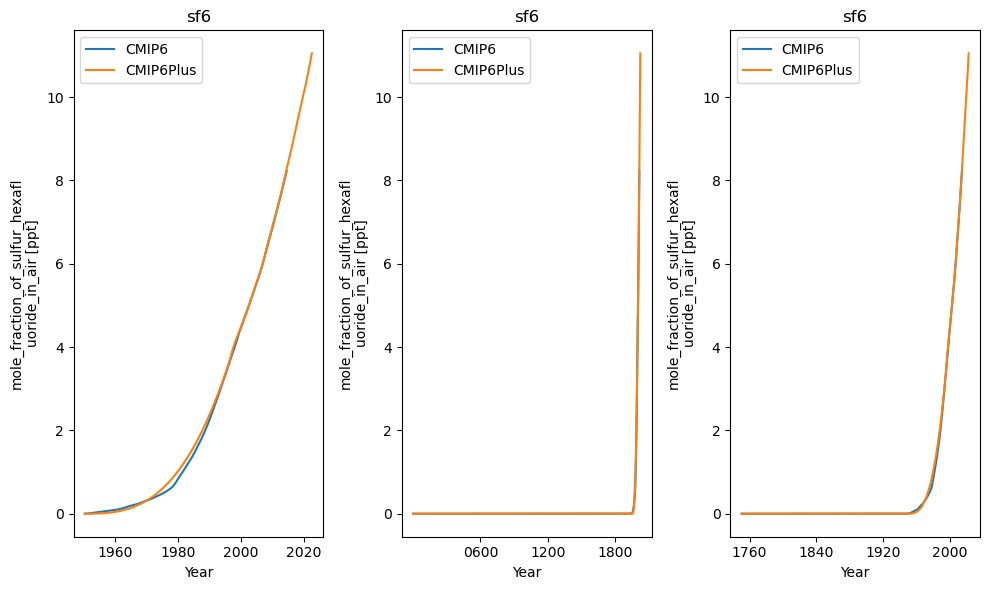

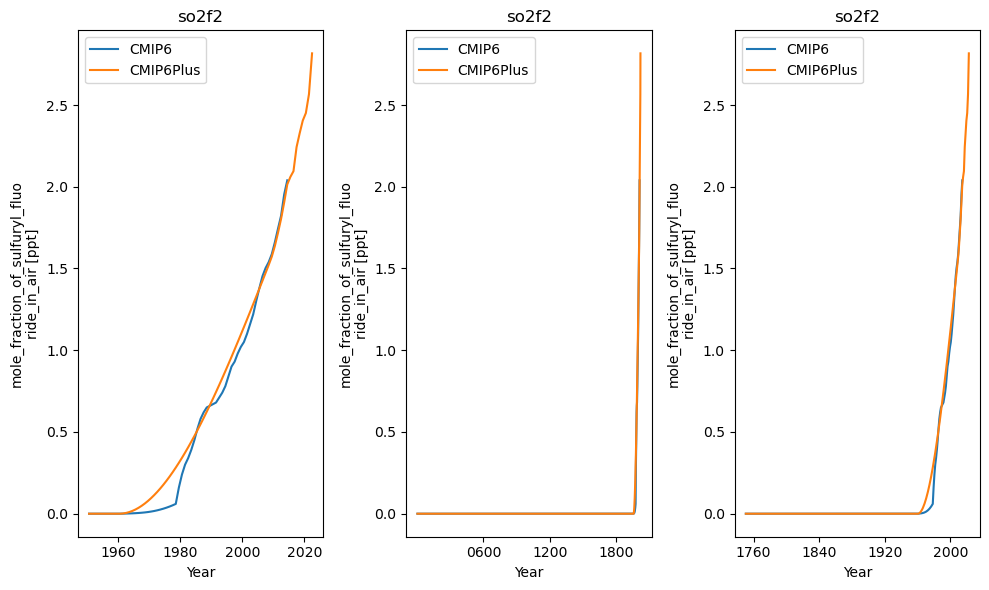

In [10]:



for specie in common_cmip6_species:
    specie_cmip6plus = CMIP6_TO_CMIP7_VARIABLE_MAP[specie]

    fig, axes = plt.subplot_mosaic([["recent", "all", "historical"]], figsize=(10, 6))
    
    #cmip6
    #ds = xr.open_dataset(spec_data_cmip6['fname'][specie], use_cftime=True)
    #ds.convert_calendar("proleptic_gregorian")

    out = xr.open_dataset(spec_data_cmip6['fname'][specie_cmip6plus], decode_times=False)
    
    if out.attrs["frequency"] == "yr":
        out = out.isel(time=slice(1, None))
    
    else:
        out = out.isel(time=slice(12, None))
    
    if out["time"].attrs["units"] == "days since 0-1-1":
        out["time"].attrs["units"] =  "days since 0001-1-1"
        old_attrs = out["time"].attrs
        out["time"] = out["time"] - 365
        out["time"].attrs = old_attrs

    out = xr.decode_cf(out, decode_times=True, use_cftime=True)

    da = out[specie]

    for time_axis, ax in ((slice(None, None), "all"), (slice('1950', None), "recent"), (slice('1750', None), "historical")):

        da.sel(time=time_axis, sector=0).plot.line(ax=axes[ax], label='CMIP6')
        # axes[ax].set_title(f'{specie_cmip6plus}')
        # axes[ax].set_xlabel('Year')
    
    ds.close()

    
    # cmip6Plus
    ds = xr.open_dataset(spec_data['fname'][specie_cmip6plus], use_cftime=True)
    ds.convert_calendar("proleptic_gregorian")

    da = ds[specie_cmip6plus]

    for time_axis, ax in ((slice(None, None), "all"), (slice('1950', None), "recent"), (slice('1750', None), "historical")):

        da.sel(time=time_axis).plot.line(ax=axes[ax], label='CMIP6Plus')
        axes[ax].set_title(f'{specie_cmip6plus}')
        axes[ax].set_xlabel('Year')
        axes[ax].legend()

    ds.close()

    fig.tight_layout()

    plt.savefig(f'plots_ghg/{specie_cmip6plus}.png', dpi=100)




/tmp/ipykernel_150/180356642.py:18: RuntimeWarning: divide by zero encountered in divide
  diff = 100*(cmip6plus_in[:2014] - cmip6_in)/cmip6_in
/tmp/ipykernel_150/180356642.py:18: RuntimeWarning: invalid value encountered in divide
  diff = 100*(cmip6plus_in[:2014] - cmip6_in)/cmip6_in
/tmp/ipykernel_150/180356642.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


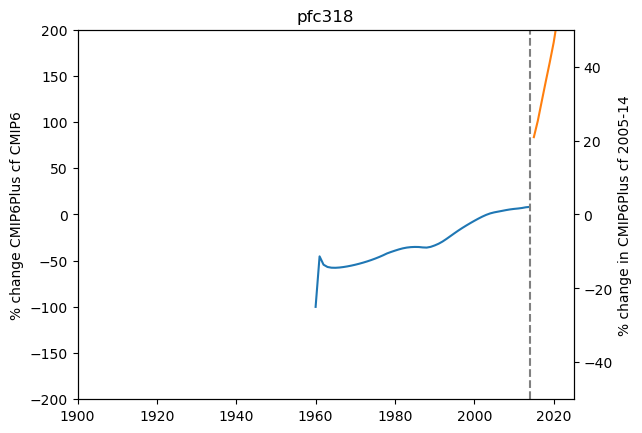

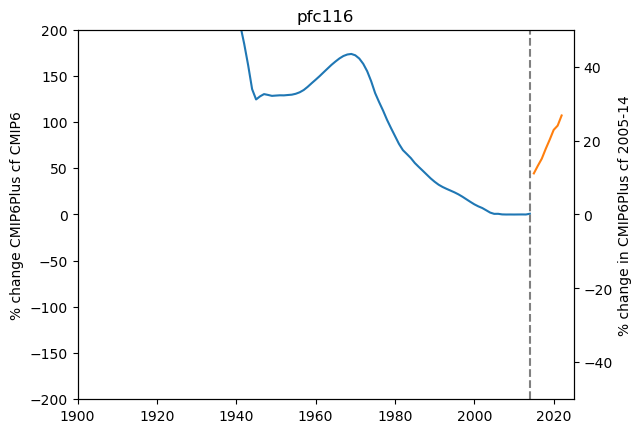

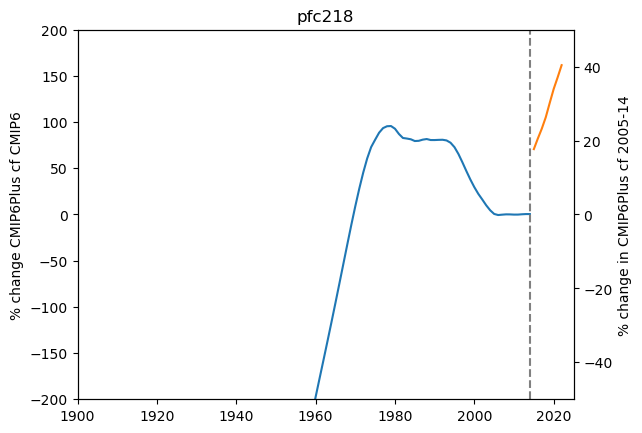

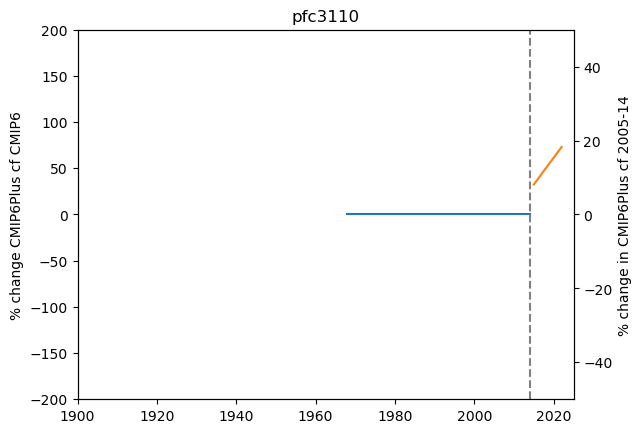

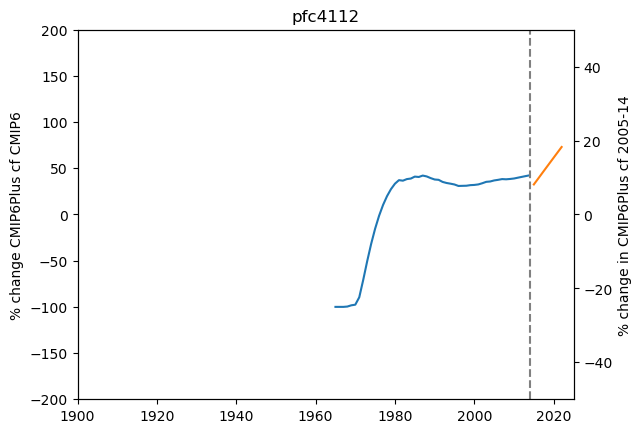

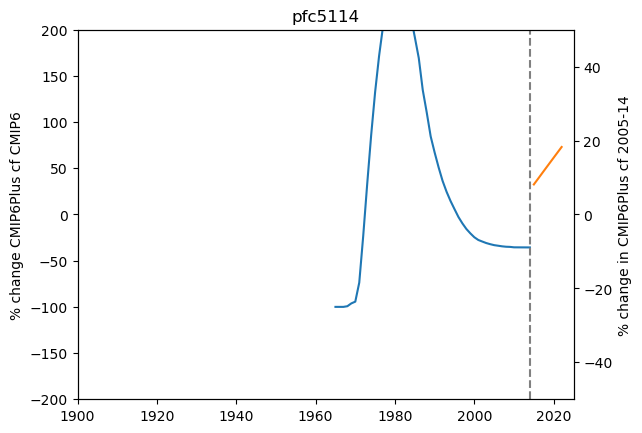

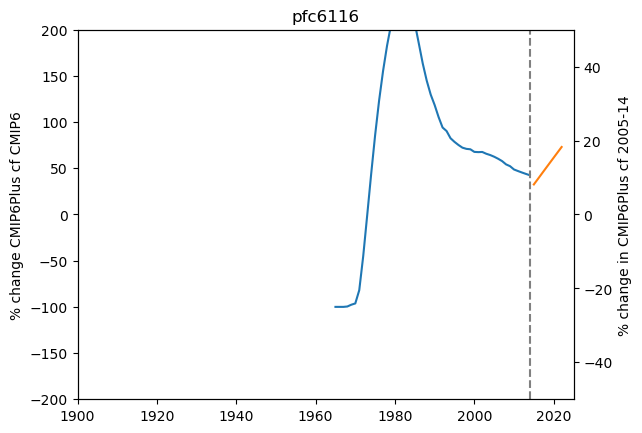

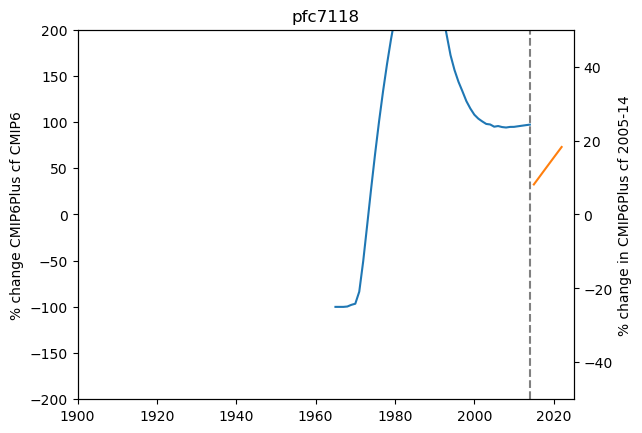

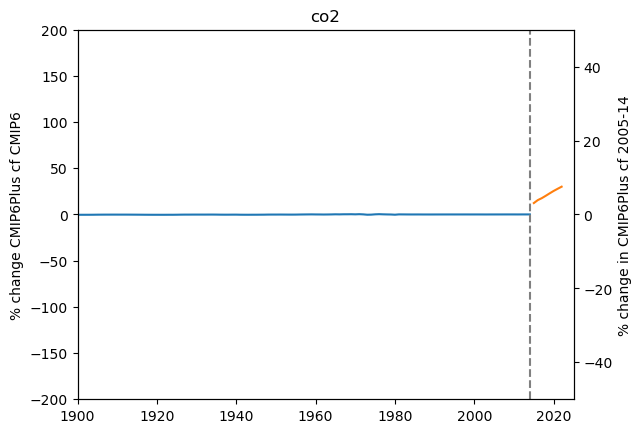

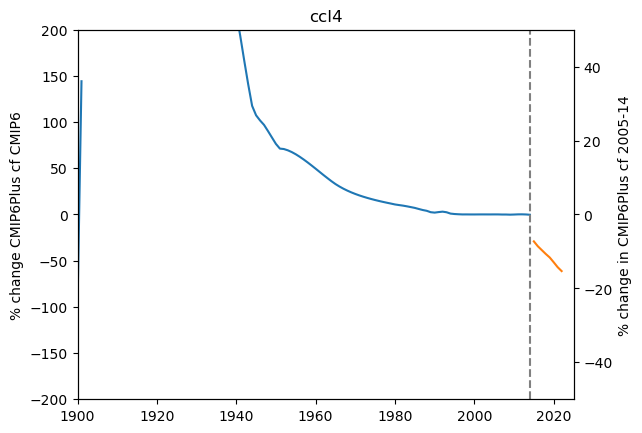

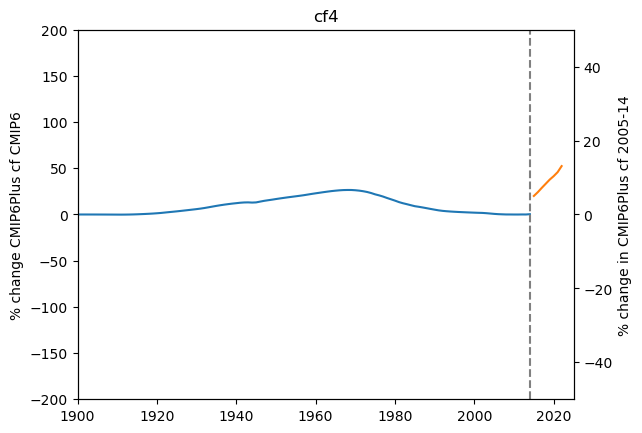

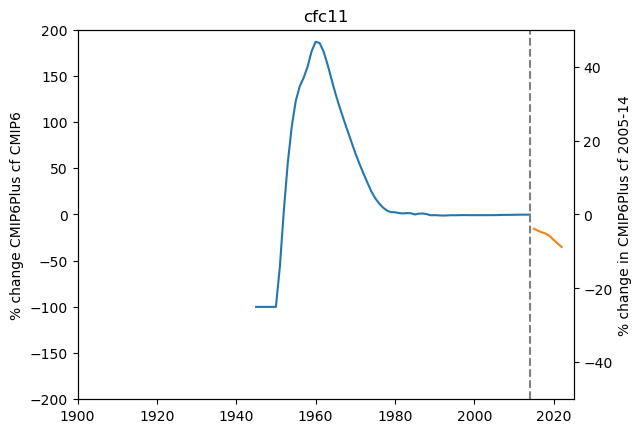

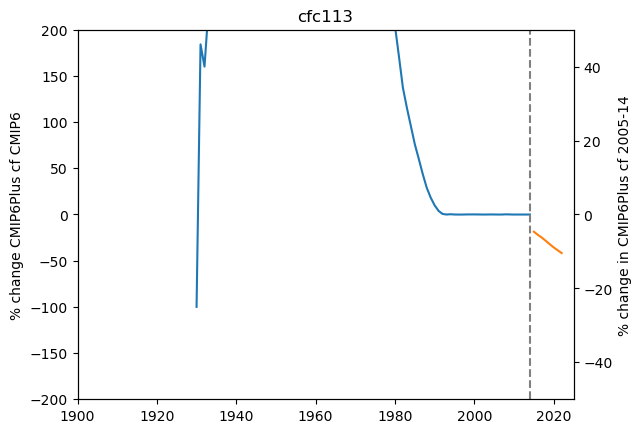

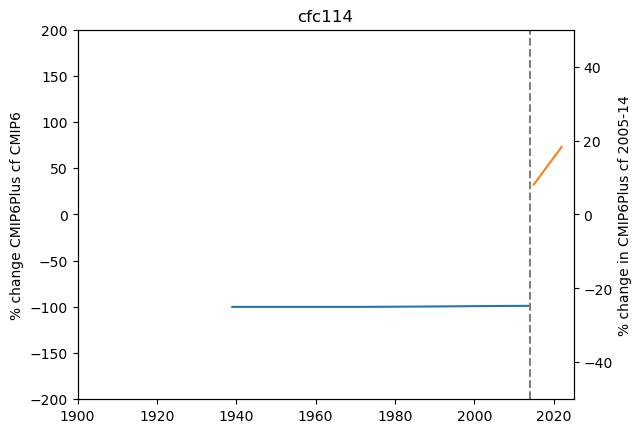

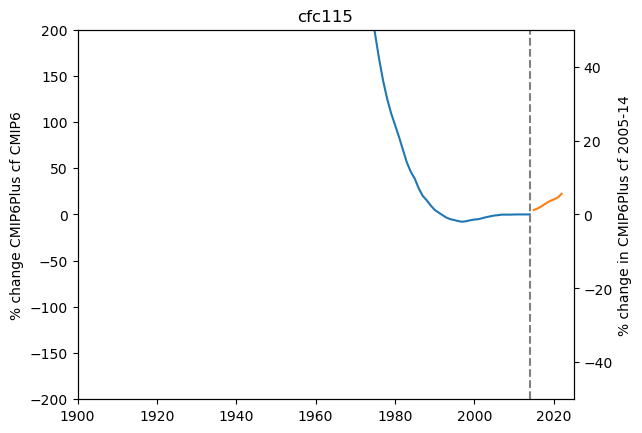

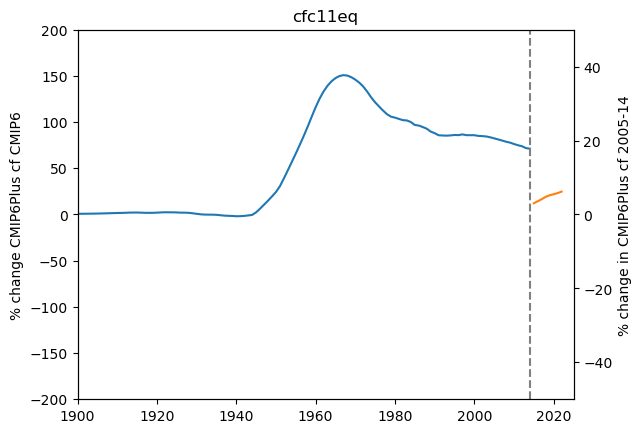

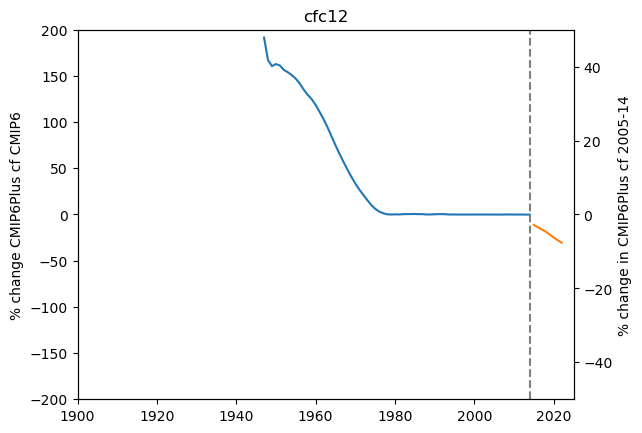

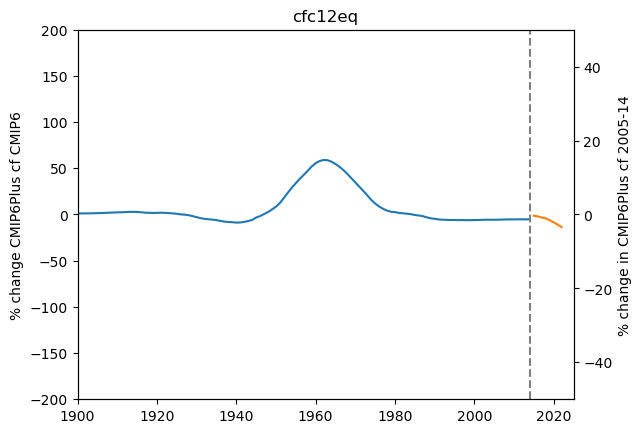

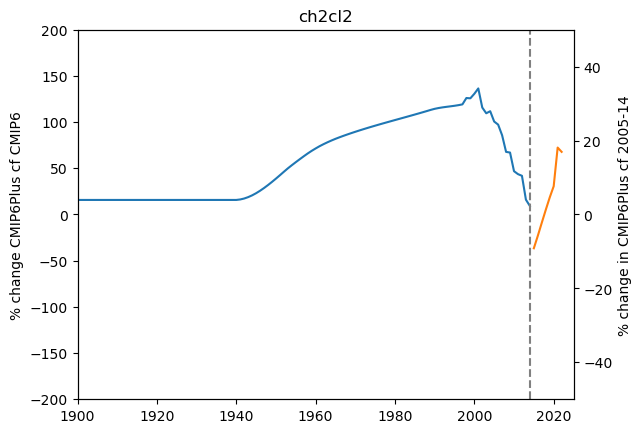

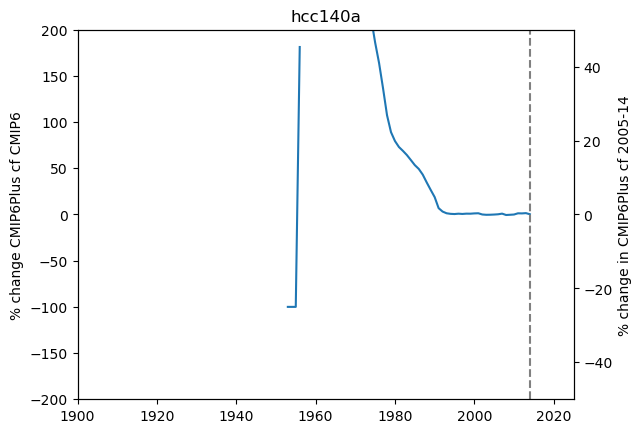

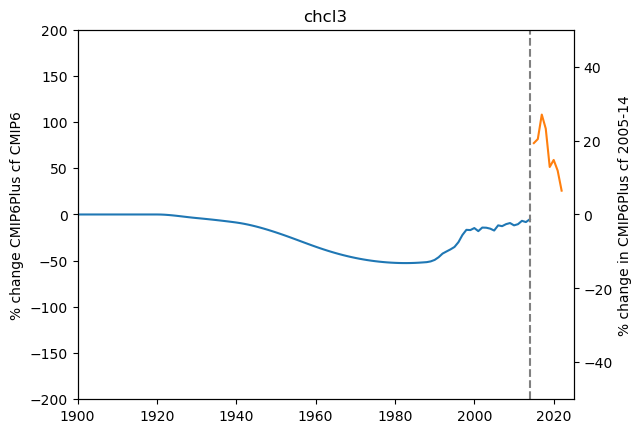

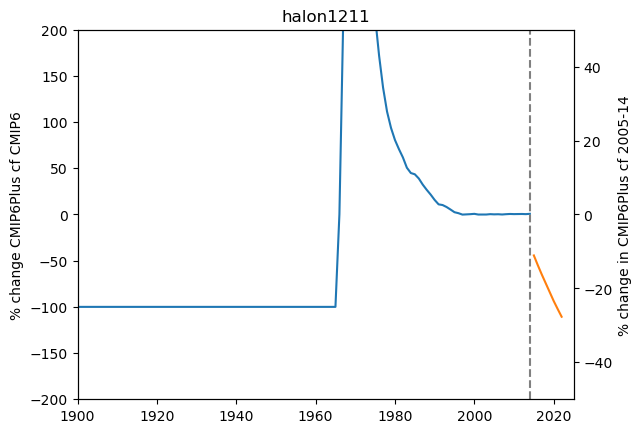

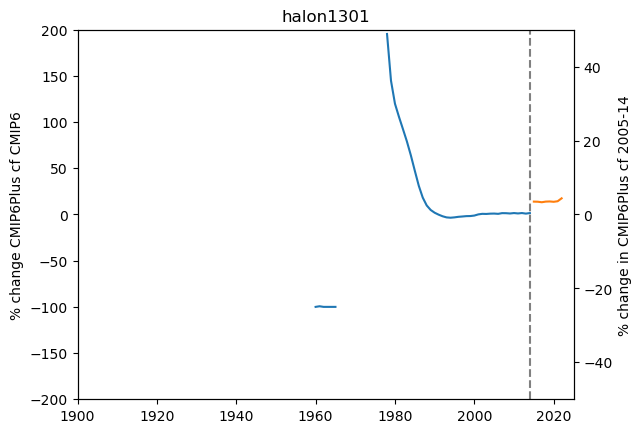

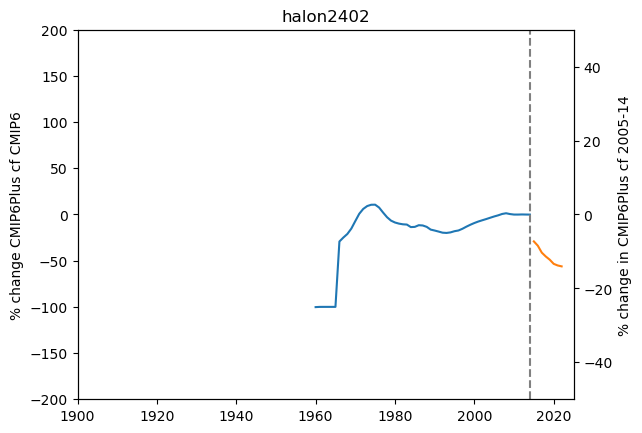

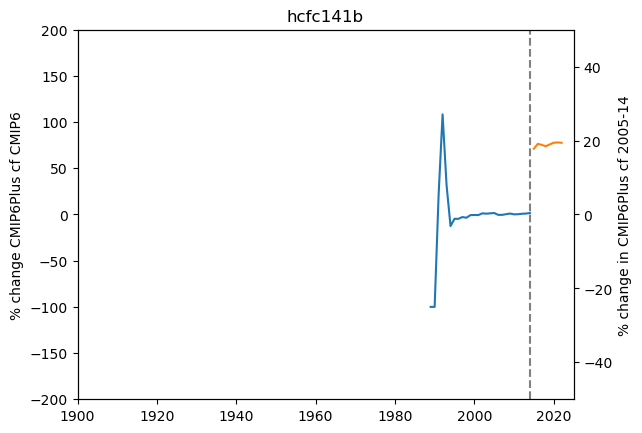

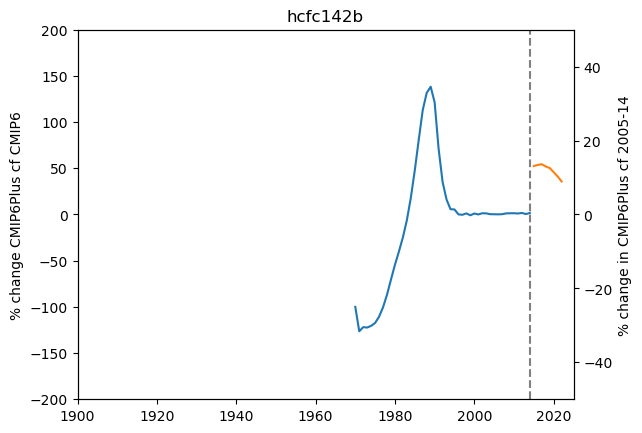

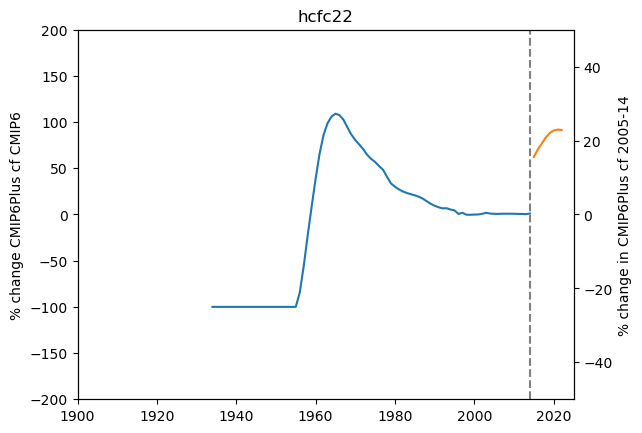

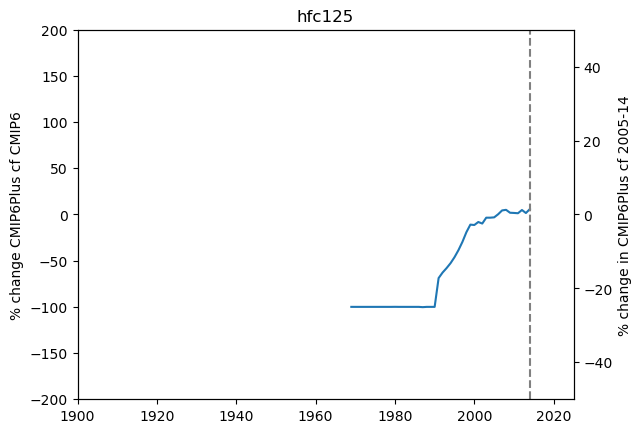

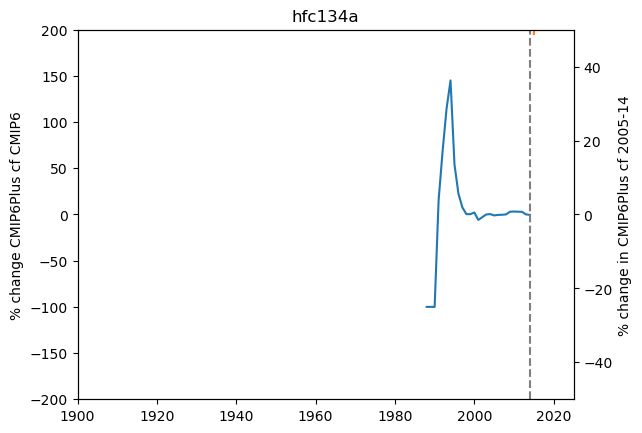

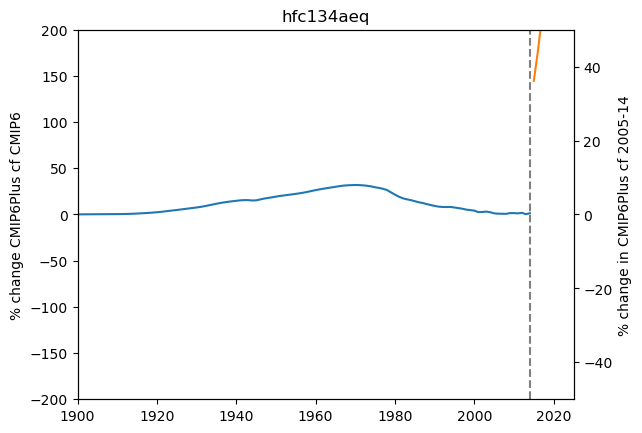

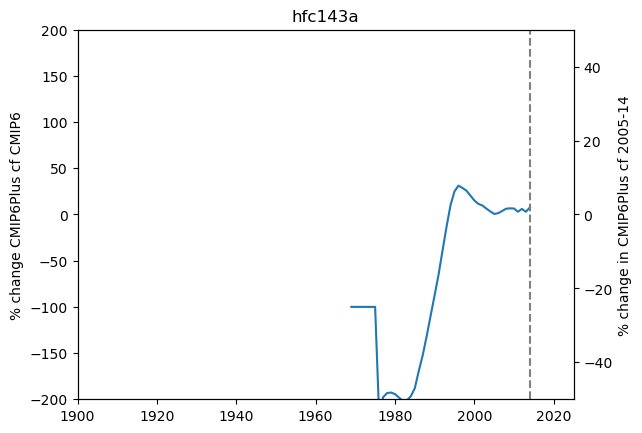

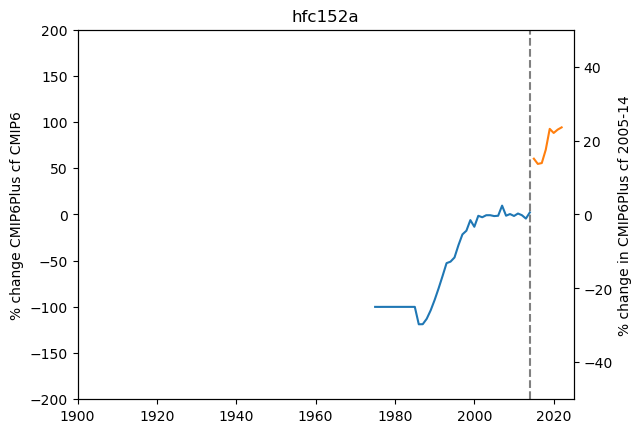

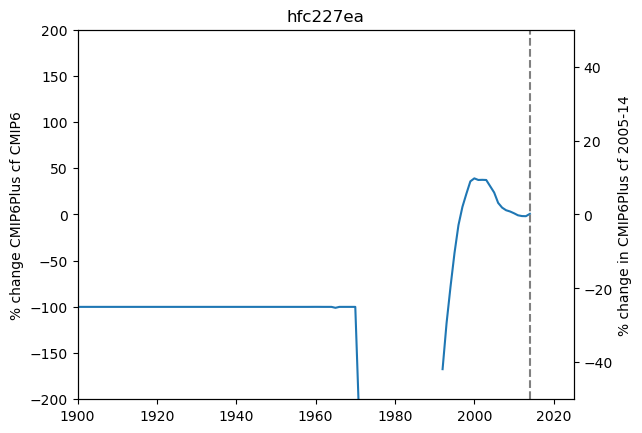

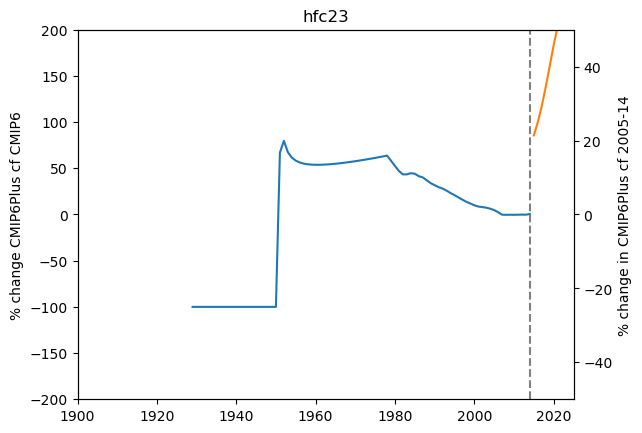

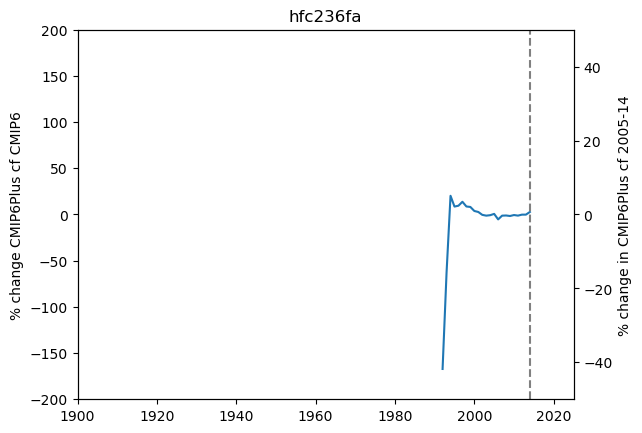

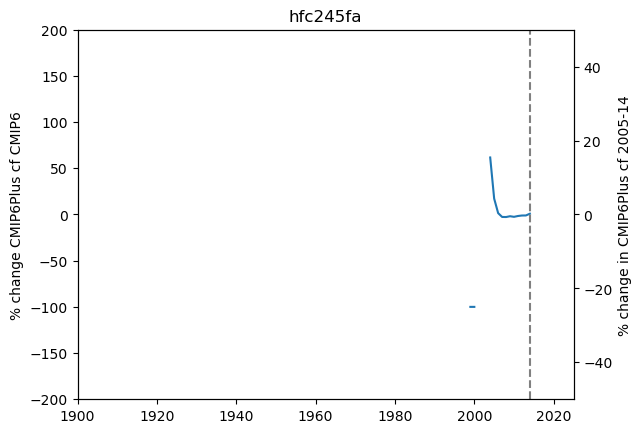

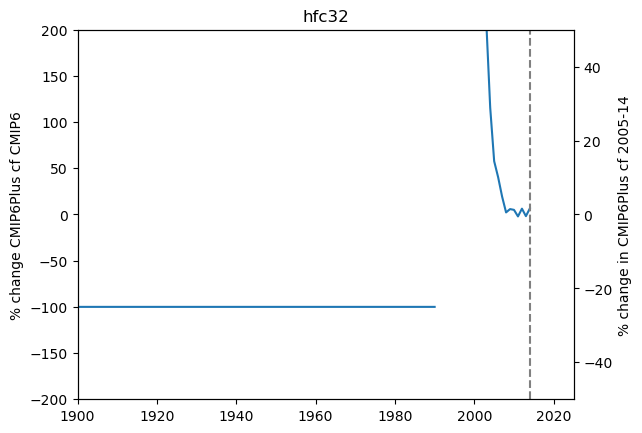

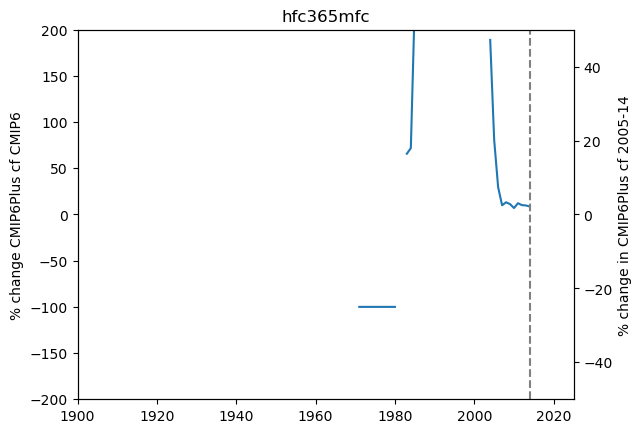

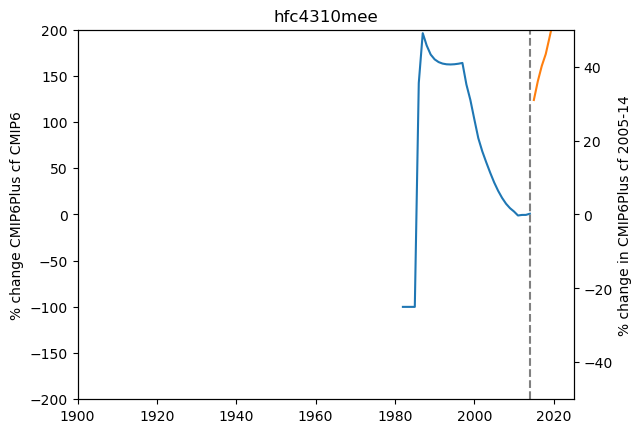

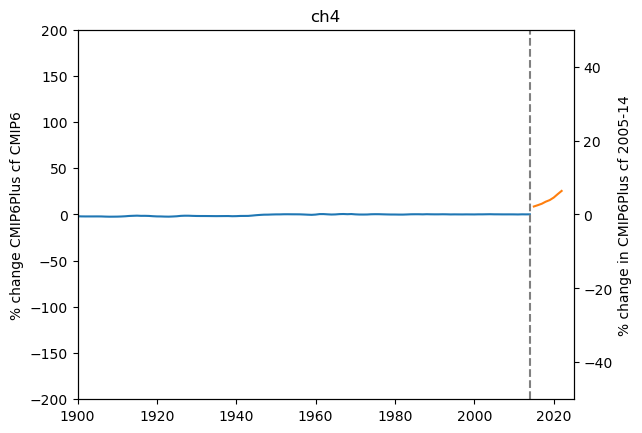

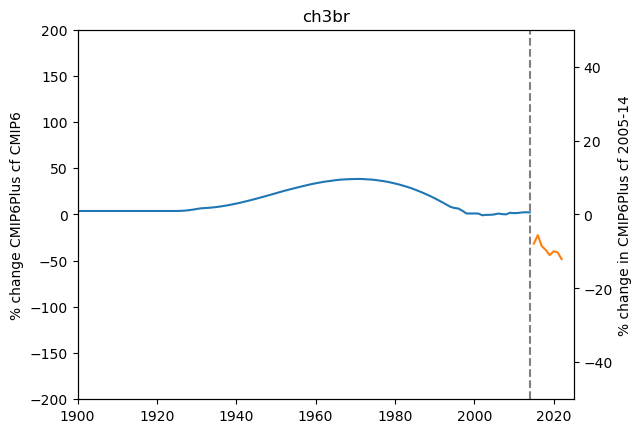

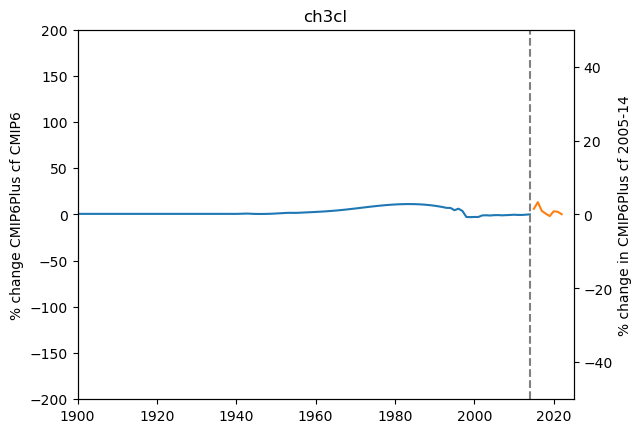

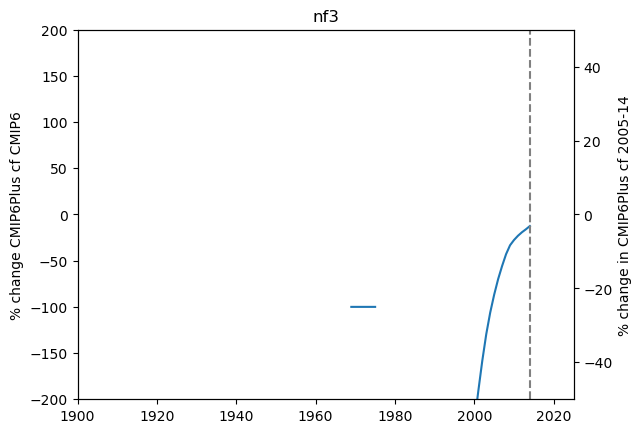

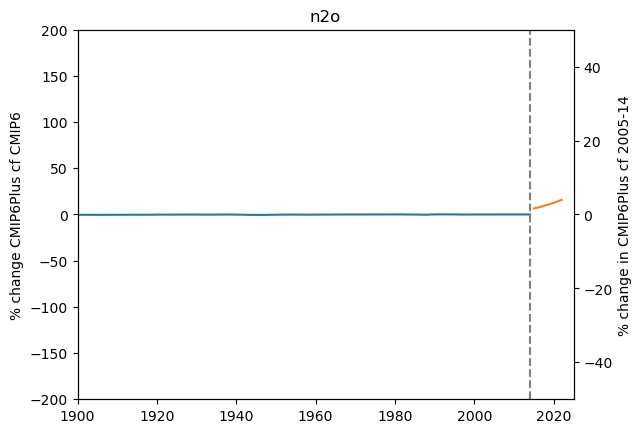

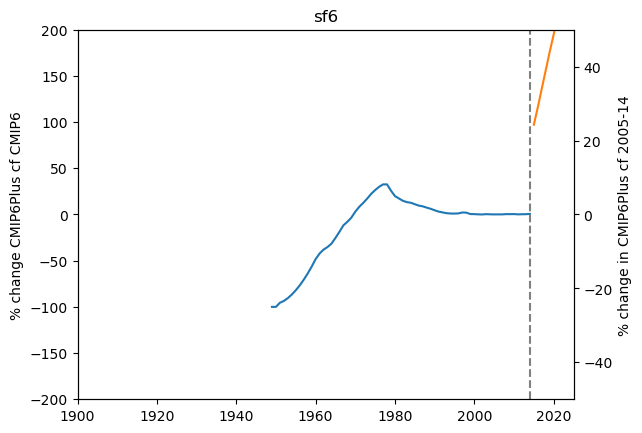

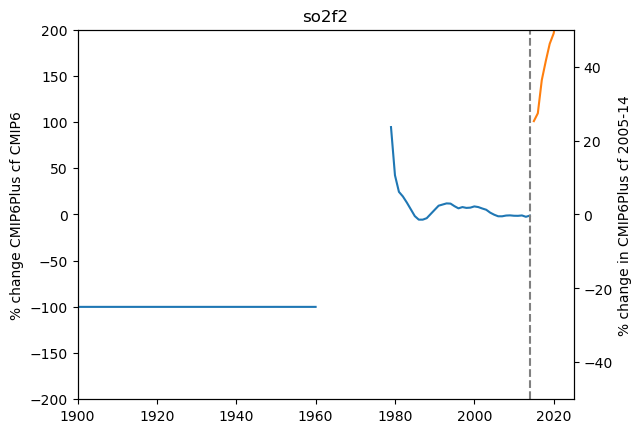

In [25]:

time = 1 + np.arange(2014)
time2 = 2015 + np.arange(8)

for specie_cmip6 in species_cmip6:

    fig = plt.figure()
    ax = fig.add_subplot(111)

    specie = CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6]

    cmip6plus_in = spec_data['data'][specie].data
    cmip6_in = spec_data_cmip6['data'][specie].data[:,0]

    #cmip6plus_in[cmip6plus_in == 0] = np.nan
    #cmip6_in[cmip6_in == 0] = np.nan


    diff = 100*(cmip6plus_in[:2014] - cmip6_in)/cmip6_in

    diff[diff >= 250] = np.nan
    diff[diff <= -250] = np.nan 
    
    ax.plot(time, diff, color='#1f77b4')
   
    ax.set_ylim([-200, 200])
    ax.set_ylabel('% change CMIP6Plus cf CMIP6')
    plt.xlim([1900, 2025])

    plt.axvline(x=2014, color='grey', linestyle='--')

    change_cf_2005_14 = 100*(cmip6plus_in[2014:] - np.mean(cmip6plus_in[2004:2014]))/np.mean(cmip6plus_in[2004:2014])

    ax2 = ax.twinx()
    ax2.plot(time2, change_cf_2005_14, color='#ff7f0e')
    ax2.set_ylim([-50, 50])
    ax2.set_ylabel('% change in CMIP6Plus cf 2005-14')

    
    plt.title(f'{specie}')
    
    plt.savefig(f'plots_hist/{specie}.png', dpi=100)







/tmp/ipykernel_2174/2636920957.py:58: RuntimeWarning: divide by zero encountered in divide
  diff = 100*(cmip6plus_in[:2014] - cmip6_in)/cmip6_in
/tmp/ipykernel_2174/2636920957.py:58: RuntimeWarning: invalid value encountered in divide
  diff = 100*(cmip6plus_in[:2014] - cmip6_in)/cmip6_in


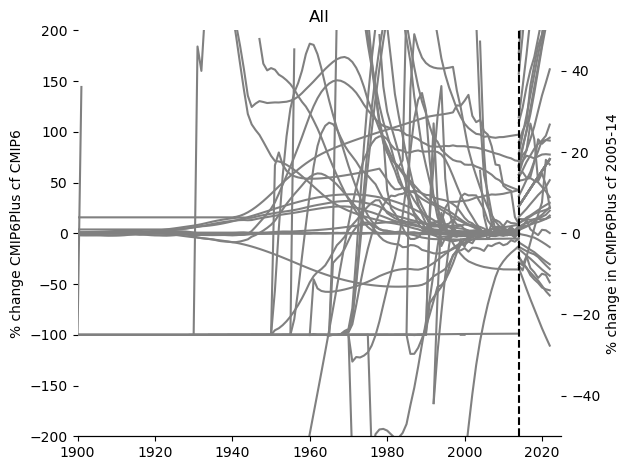

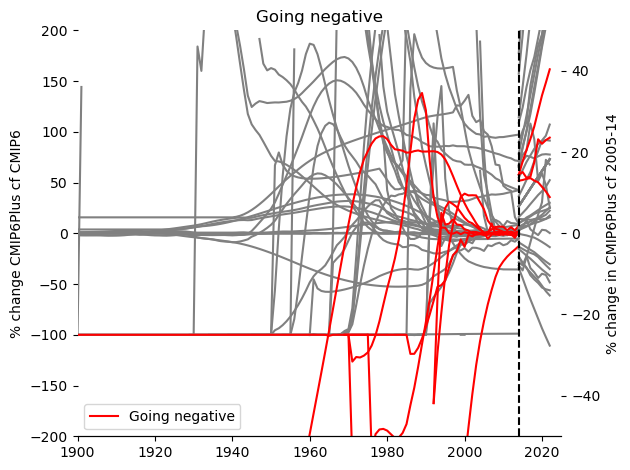

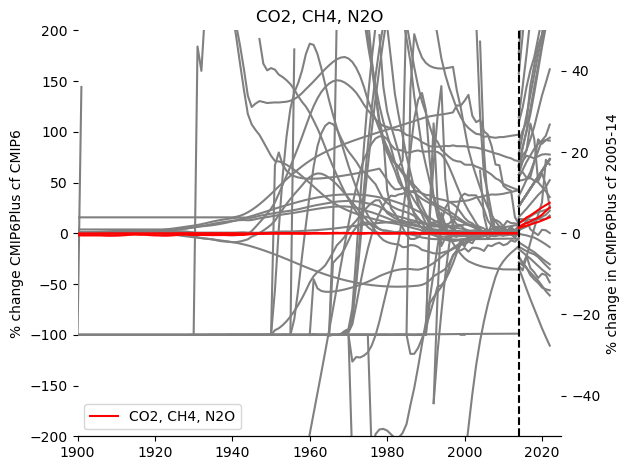

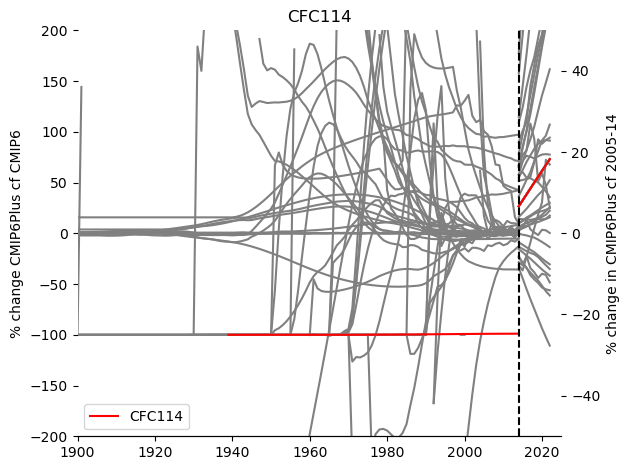

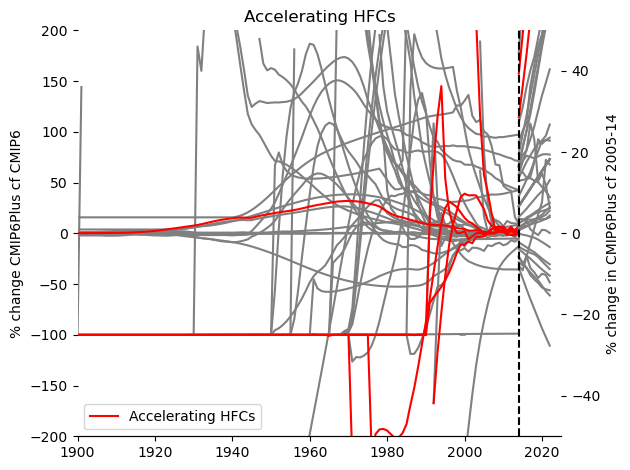

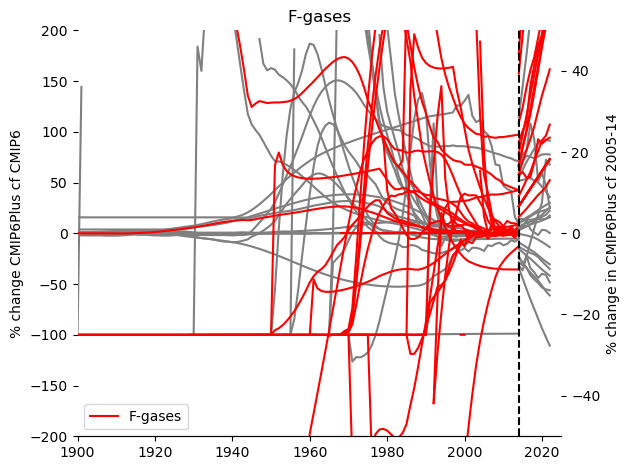

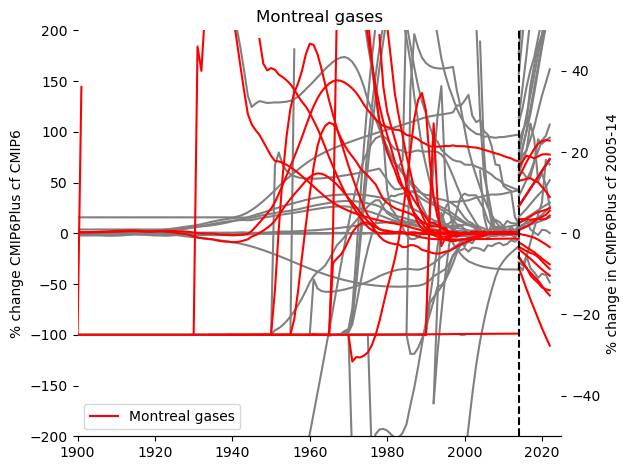

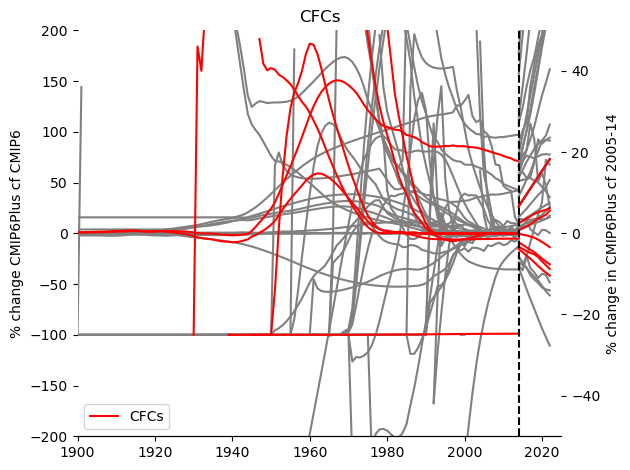

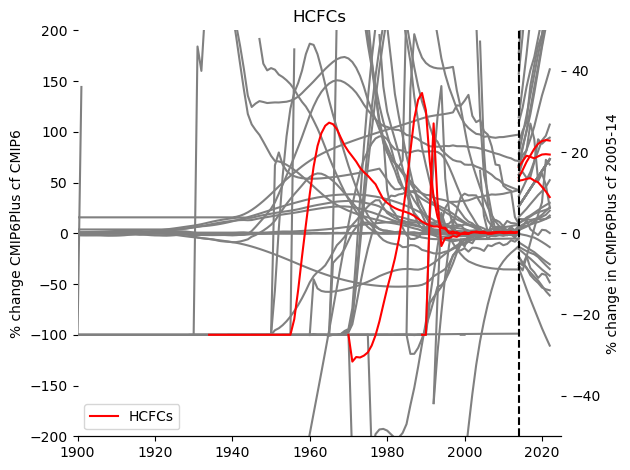

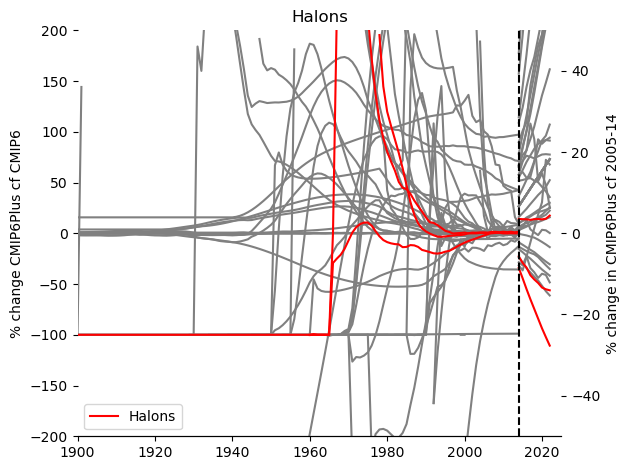

In [20]:

time = 1 + np.arange(2014)
time2 = 2014 + np.arange(9)

f_gases = ['cf4', 'pfc116', 'pfc218', 'pfc318', 'pfc6116', 'pfc7118', 'nf3', 'sf6', 'so2f2', 'hfc125', 'hfc134a', 'hfc143a', 'hfc152a', 'hfc227ea',
 'hfc23', 'hfc236fa', 'hfc245fa', 'hfc32', 'hfc365mfc', 'pfc3110', 'pfc4112', 'pfc5114', 'hfc4310mee']

montreals = ['cfc11', 'cfc113', 'cfc114', 'cfc115', 'cfc11eq', 'cfc12', 
             'cfc12eq', 'hcfc141b', 'hcfc142b', 'hcfc22', 'ccl4', 'halon1211',
             'halon1301', 'halon2402']

cfcs = ['cfc11', 'cfc113', 'cfc114', 'cfc115', 'cfc11eq', 'cfc12', 'cfc12eq']

hcfcs = ['hcfc141b', 'hcfc142b', 'hcfc22']

halons = ['halon1211', 'halon1301', 'halon2402']

var_groups = {
    #'All':[],
    'Going negative':['pfc218', 'hcfc142b', 'hfc143a', 'hfc152a', 'hfc227ea', 'hfc236fa', 'nf3'],
    'CO2, CH4, N2O':['co2', 'ch4', 'n2o'],
    'CFC114':['cfc114'],
    'Accelerating HFCs':['hfc32', 'hfc125', 'hfc134a', 'hfc134aeq', 'hfc143a', 'hfc227ea'],
    'F-gases':f_gases,
    'Montreal gases':montreals,
    'CFCs':cfcs,
    'HCFCs':hcfcs,
    'Halons':halons,
    }

for var_group in var_groups.keys():

    speclist = var_groups[var_group]

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax2 = ax.twinx()

    specs_ordered = copy.deepcopy(list(CMIP6_TO_CMIP7_VARIABLE_MAP.values()))    
    specs_ordered = [e for e in specs_ordered if e not in speclist]
    
    specs_ordered.extend(speclist)

    for specie in specs_ordered:

        color='grey'
        zorder=1
        linewidth = 1
        if specie in speclist:
            color='red'
            zorder=2
    
        cmip6plus_in = spec_data['data'][specie].data
        cmip6_in = spec_data_cmip6['data'][specie].data[:,0]
    
        #cmip6plus_in[cmip6plus_in == 0] = np.nan
        #cmip6_in[cmip6_in == 0] = np.nan
    
    
        diff = 100*(cmip6plus_in[:2014] - cmip6_in)/cmip6_in
    
        diff[diff >= 250] = np.nan
        diff[diff <= -250] = np.nan 
        
        ax.plot(time, diff, color=color)
       
    
        change_cf_2005_14 = 100*(cmip6plus_in[2013:] - np.mean(cmip6plus_in[2004:2014]))/np.mean(cmip6plus_in[2004:2014])
    
        ax2.plot(time2, change_cf_2005_14, color=color)
        
    

    ax.set_ylim([-200, 200])
    ax.set_ylabel('% change CMIP6Plus cf CMIP6')
    plt.xlim([1900, 2025])
    
    plt.axvline(x=2014, color='black', linestyle='--')

    ax2.set_ylim([-50, 50])
    ax2.set_ylabel('% change in CMIP6Plus cf 2005-14')
    plt.title(f'{var_group}')

    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["top"].set_visible(False)


    if len(speclist) > 0:
        handles = []
        handles.append(Line2D([0], [0], label=var_group, color='red'))
        plt.legend(handles=handles, loc='lower left')

    plt.tight_layout()
    plt.savefig(f'plots_for_reading/{var_group}.png', dpi=100)
    wef
    


In [11]:
neg_specs = []
for specie_cmip6 in species_cmip6:

    specie = CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6]

    cmip6plus_in = spec_data['data'][specie].data

    neg_values = sum(n < -0.0001 for n in cmip6plus_in)

    if neg_values > 0:
        print(specie)
        print(neg_values)
        neg_specs.append(specie)

print(neg_specs)

pfc218
73
hcfc142b
7
hfc143a
14
hfc152a
4
hfc227ea
23
hfc236fa
22
nf3
29
['pfc218', 'hcfc142b', 'hfc143a', 'hfc152a', 'hfc227ea', 'hfc236fa', 'nf3']


In [12]:
montreal_specs = []
for specie_cmip6 in species_cmip6:
    specie = CMIP6_TO_CMIP7_VARIABLE_MAP[specie_cmip6]

    if 'cfc' in specie or 'CFC' in specie:# or'cfc' in specie or'cfc' in specie or:
        montreal_specs.append(specie)

print(montreal_specs)

['cfc11', 'cfc113', 'cfc114', 'cfc115', 'cfc11eq', 'cfc12', 'cfc12eq', 'hcfc141b', 'hcfc142b', 'hcfc22']


In [70]:
f_gases = ['CF4', 'C2F6', 'C3F8', 'c-C4F8', 'n-C4F10', 'n-C5F12',
       'n-C6F14', 'i-C6F14', 'C7F16', 'C8F18', 'NF3', 'SF6', 'SO2F2', 'HFC-125',
       'HFC-134a', 'HFC-143a', 'HFC-152a', 'HFC-227ea', 'HFC-23',
       'HFC-236fa', 'HFC-245fa', 'HFC-32', 'HFC-365mfc', 'HFC-43-10mee']


cmip6_to_fair = {
    # 'mole_fraction_of_carbon_dioxide_in_air': 'co2',
 # 'mole_fraction_of_methane_in_air': 'ch4',
 # 'mole_fraction_of_nitrous_oxide_in_air': 'n2o',
 'mole_fraction_of_c2f6_in_air':'C2F6',
 'mole_fraction_of_c3f8_in_air':'C3F8',
 'mole_fraction_of_c4f10_in_air':'C4F10',
 'mole_fraction_of_c5f12_in_air':'C5F12',
 'mole_fraction_of_c6f14_in_air':'C6F14',
 'mole_fraction_of_c7f16_in_air':'C7F16',
 'mole_fraction_of_c8f18_in_air':'C8F18',
 'mole_fraction_of_c_c4f8_in_air':'c-C4F8',
 'mole_fraction_of_carbon_tetrachloride_in_air':'CCl4',
 'mole_fraction_of_cf4_in_air':'CF4',
 'mole_fraction_of_cfc11_in_air':'CFC-11',
 'mole_fraction_of_cfc113_in_air':'CFC-113',
 'mole_fraction_of_cfc114_in_air':'CFC-114',
 'mole_fraction_of_cfc115_in_air':'CFC-115',
 'mole_fraction_of_cfc12_in_air':'CFC-12',
 'mole_fraction_of_ch2cl2_in_air':'CH2Cl2',
 'mole_fraction_of_methyl_bromide_in_air':'CH3Br',
 'mole_fraction_of_ch3ccl3_in_air':'CH3CCl3',
 'mole_fraction_of_methyl_chloride_in_air':'CH3Cl',
 'mole_fraction_of_chcl3_in_air':'CHCl3',
 'mole_fraction_of_halon1211_in_air':'Halon-1211',
 'mole_fraction_of_halon1301_in_air':'Halon-1301',
 'mole_fraction_of_halon2402_in_air':'Halon-2402',
 'mole_fraction_of_hcfc141b_in_air':'HCFC-141b',
 'mole_fraction_of_hcfc142b_in_air':'HCFC-142b',
 'mole_fraction_of_hcfc22_in_air':'HCFC-22',
 'mole_fraction_of_hfc125_in_air':'HFC-125',
 'mole_fraction_of_hfc134a_in_air':'HFC-134a',
 'mole_fraction_of_hfc143a_in_air':'HFC-143a',
 'mole_fraction_of_hfc152a_in_air':'HFC-152a',
 'mole_fraction_of_hfc227ea_in_air':'HFC-227ea',
 'mole_fraction_of_hfc23_in_air':'HFC-23',
 'mole_fraction_of_hfc236fa_in_air':'HFC-236fa',
 'mole_fraction_of_hfc245fa_in_air':'HFC-245fa',
 'mole_fraction_of_hfc32_in_air':'HFC-32',
 'mole_fraction_of_hfc365mfc_in_air':'HFC-365mfc',
 'mole_fraction_of_hfc4310mee_in_air':'HFC-4310mee',
 'mole_fraction_of_nf3_in_air':'NF3',
 'mole_fraction_of_sf6_in_air':'SF6',
 'mole_fraction_of_so2f2_in_air':'SO2F2',
 # 'mole_fraction_of_cfc11eq_in_air':'CFC11eq',
 # 'mole_fraction_of_cfc12eq_in_air':'CFC12eq',
 # 'mole_fraction_of_hfc134aeq_in_air':'HFC-134aeq',
    
    }

fair_to_cmip6 = {}

for spec in cmip6_to_fair.keys():
    fair_to_cmip6[cmip6_to_fair[spec]] = spec

f_gas_list = []
for f_gas in f_gases:
    if f_gas in fair_to_cmip6.keys():    
        f_gas_list.append(CMIP6_TO_CMIP7_VARIABLE_MAP[fair_to_cmip6[f_gas]])
    else:
        print(f_gas)

n-C4F10
n-C5F12
n-C6F14
i-C6F14
HFC-43-10mee


In [14]:
list(CMIP6_TO_CMIP7_VARIABLE_MAP.values())

['co2',
 'ch4',
 'n2o',
 'pfc116',
 'pfc218',
 'pfc3110',
 'pfc4112',
 'pfc5114',
 'pfc6116',
 'pfc7118',
 'pfc318',
 'ccl4',
 'cf4',
 'cfc11',
 'cfc113',
 'cfc114',
 'cfc115',
 'cfc12',
 'ch2cl2',
 'ch3br',
 'hcc140a',
 'ch3cl',
 'chcl3',
 'halon1211',
 'halon1301',
 'halon2402',
 'hcfc141b',
 'hcfc142b',
 'hcfc22',
 'hfc125',
 'hfc134a',
 'hfc143a',
 'hfc152a',
 'hfc227ea',
 'hfc23',
 'hfc236fa',
 'hfc245fa',
 'hfc32',
 'hfc365mfc',
 'hfc4310mee',
 'nf3',
 'sf6',
 'so2f2',
 'cfc11eq',
 'cfc12eq',
 'hfc134aeq']

In [69]:
len(f_gases)

24